## **Requirements**

### Mode 1 — Local (VSCode only)

#### Java
PySpark requires Java to run. **Java 17 is required** — newer versions
(18+) are not fully compatible with the current Spark version.

1. Download and install **Eclipse Temurin JDK 17** from:  
   https://adoptium.net/temurin/releases/?version=17
2. After installing, set `JAVA_HOME` in Windows System Environment Variables
   to the JDK 17 installation path, e.g.:  
   `C:\Users\YourUser\AppData\Local\Programs\Eclipse Adoptium\jdk-17.x.x-hotspot`
3. Confirm the correct version is active:
```bash
   java -version
   # Expected: openjdk version "17.x.x"
```

#### Python
- Python 3.8 or higher

#### Libraries
```bash
pip install pyspark
```

---

### Mode 2 — Google Cloud Dataproc (recommended for performance)

Processes data in parallel across multiple machines — queries and ML 
models run significantly faster than local mode.

> ⚠️ **There is no pause option in Dataproc.** The recommended workflow 
> is to **create the cluster when you start working and delete it when 
> you finish**. The data stays safely in the Google Cloud Storage bucket 
> and is never lost. You are only charged while the cluster exists.

#### One-time setup
1. Create a **Google Cloud account** and activate billing
2. Upload the 12 Parquet files to a **Google Cloud Storage** bucket
3. Install **Google Cloud SDK**: https://cloud.google.com/sdk/docs/install
4. Initialise the SDK and set the default region:
```bash
   gcloud init
   # Select your project and choose europe-west1 as default region
```

---

#### Every time you want to work

**Step 1** — Create the cluster (~3 minutes):
```bash
gcloud dataproc clusters create cluster-taxi --region=europe-west1 --zone=europe-west1-b --master-machine-type=n2-standard-4 --worker-machine-type=n2-standard-4 --num-workers=2 --image-version=2.1
gcloud dataproc clusters create cluster-taxi --region=us-central1 --zone=us-central1-a --master-machine-type=n2-standard-4 --worker-machine-type=n2-standard-4 --num-workers=2 --image-version=2.1
```

**Step 2** — Open a terminal and create the SSH tunnel (keep it open):
```bash
gcloud compute ssh cluster-taxi-m --zone=europe-west1-b -- -L 8888:localhost:8888
gcloud compute ssh cluster-taxi-m --zone=us-central1-a -- -L 8888:localhost:8888
```

**Step 3** — In the SSH window that opens, start Jupyter:
```bash
jupyter notebook --no-browser --port=8888
```

**Step 4** — In the SSH window, after running the Jupyter command, 
a URL will appear automatically, e.g.:
http://localhost:8888/?token=YOUR_TOKEN_HERE

Copy this full URL — the token changes every time Jupyter starts.

**Step 5** — In VSCode, click the kernel selector (top right) →
**Select Another Kernel** → **Existing Jupyter Server** → paste the URL

**Step 6** — Work normally in VSCode. Your data is read directly 
from the bucket:
```python
files = [f"gs://YOUR_BUCKET_NAME/yellow_tripdata_2020-{str(i).zfill(2)}.parquet" 
         for i in range(1, 13)]
```

**Step 7** — When finished, **always delete the cluster** to avoid charges:
```bash
gcloud dataproc clusters delete cluster-taxi --region=europe-west1
gcloud dataproc clusters delete cluster-taxi --region=us-central1
```

In [50]:
# ── Standard Library ────────────────────────────────────────────
import time
import glob
from collections import Counter
from functools import reduce
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import io

# ── PySpark Core ─────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    LongType, DoubleType, StringType, TimestampType
)
from pyspark.sql.functions import percentile_approx

# ── PySpark ML ───────────────────────────────────────────────────
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [4]:
spark = SparkSession.builder \
    .appName("AnalisePatricia") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(spark.sparkContext._jvm.System.getProperty("java.version"))

11.0.30


In [5]:
files = [f"gs://taxi-data-2020-patricia/yellow_tripdata_2020-{str(i).zfill(2)}.parquet" for i in range(1, 13)]
print(files)

['gs://taxi-data-2020-patricia/yellow_tripdata_2020-01.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-02.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-03.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-04.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-05.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-06.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-07.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-08.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-09.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-10.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-11.parquet', 'gs://taxi-data-2020-patricia/yellow_tripdata_2020-12.parquet']


In [6]:
df = spark.read.parquet(*files) \
    .withColumn("airport_fee", F.col("airport_fee").cast("double"))

#### **Schema Inconsistency — `airport_fee`**

The `airport_fee` column presented type inconsistencies across the 12 Parquet files (`INT32`, `DOUBLE`, and `VOID`), causing schema conversion errors at read time. Since this field was not applicable in 2020 — it was only introduced by the NYC TLC in 2022 — it was dropped immediately upon loading to avoid conflicts.

The `airport_fee` field shows a near-total absence of values (**~99.99%**), which is expected: this surcharge was only introduced by the NYC TLC in 2022 and did not exist in 2020. This column will be dropped prior to analysis.

In [7]:
df = df.drop("airport_fee")

df.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|1       |2020-01-01 00:28:15 |2020-01-01 00:33:03  |1.0            |1.2          |1.0       |N                 |238         |239         |1           |6.0        |3.0  |0.5    |1.47      |0.0         |0.3                  

In [8]:
for f in files:
    temp_df = spark.read.parquet(f).withColumn("airport_fee", F.col("airport_fee").cast("double"))
    print(f"{f.split('/')[-1]} → {temp_df.count()} linhas, {len(temp_df.columns)} colunas")

yellow_tripdata_2020-01.parquet → 6405008 linhas, 19 colunas
yellow_tripdata_2020-02.parquet → 6299367 linhas, 19 colunas
yellow_tripdata_2020-03.parquet → 3007687 linhas, 19 colunas
yellow_tripdata_2020-04.parquet → 238073 linhas, 19 colunas
yellow_tripdata_2020-05.parquet → 348415 linhas, 19 colunas
yellow_tripdata_2020-06.parquet → 549797 linhas, 19 colunas
yellow_tripdata_2020-07.parquet → 800412 linhas, 19 colunas
yellow_tripdata_2020-08.parquet → 1007286 linhas, 19 colunas
yellow_tripdata_2020-09.parquet → 1341017 linhas, 19 colunas
yellow_tripdata_2020-10.parquet → 1681132 linhas, 19 colunas
yellow_tripdata_2020-11.parquet → 1509000 linhas, 19 colunas
yellow_tripdata_2020-12.parquet → 1461898 linhas, 19 colunas


# **1. Dataset Overview**

### **Dimensions**

In [9]:
# ── 1. DIMENSÕES GERAIS ──────────────────────────────────────────
total_rows = df.count()
total_cols = len(df.columns)
print(f"Total de linhas: {total_rows:,}")
print(f"Total de colunas: {total_cols}")

Total de linhas: 24,649,092
Total de colunas: 18


### **Data Types**

In [10]:
# ── 2. SCHEMA POR TIPOS ─────────────────────────────────────────
type_counts = Counter([str(f.dataType) for f in df.schema.fields])
for t, count in type_counts.items():
    print(f"{t}: {count} colunas")

LongType(): 4 colunas
TimestampType(): 2 colunas
DoubleType(): 11 colunas
StringType(): 1 colunas


The dataset comprises **18 attributes** distributed across 4 data types:

- **LongType** (4 columns): Integer fields representing IDs and categorical codes — `VendorID`, `PULocationID`, `DOLocationID`, and `payment_type`.

- **TimestampNTZType** (2 columns): Datetime fields without timezone — `tpep_pickup_datetime` and `tpep_dropoff_datetime`.

- **DoubleType** (11 columns): Continuous numerical fields representing distances, fare components, and trip metadata.

- **StringType** (1 column): The `store_and_fwd_flag` field, indicating whether the trip record was temporarily stored before transmission (Y/N).

### **Dataset Attributes**

| Field Name | Type | Description |
|---|---|---|
| `VendorID` | Long | Identifies the technology provider that recorded the trip. **1** = Creative Mobile Technologies, **2** = VeriFone Inc. |
| `tpep_pickup_datetime` | Timestamp | Date and time when the taximeter was engaged (trip start). |
| `tpep_dropoff_datetime` | Timestamp | Date and time when the taximeter was disengaged (trip end). |
| `passenger_count` | Double | Number of passengers in the vehicle, manually entered by the driver. |
| `trip_distance` | Double | Total trip distance in miles as reported by the taximeter. |
| `RatecodeID` | Double | Rate code applied at the end of the trip. **1** = Standard, **2** = JFK, **3** = Newark, **4** = Nassau/Westchester, **5** = Negotiated, **6** = Group ride. |
| `store_and_fwd_flag` | String | Indicates whether the trip record was temporarily stored in the vehicle due to lack of server connection before being transmitted. **Y** = stored, **N** = not stored. |
| `PULocationID` | Long | TLC Taxi Zone ID where the passenger was picked up. |
| `DOLocationID` | Long | TLC Taxi Zone ID where the passenger was dropped off. |
| `payment_type` | Long | Payment method used. **1** = Credit card, **2** = Cash, **3** = No charge, **4** = Dispute, **5** = Unknown, **6** = Voided. |
| `fare_amount` | Double | Base fare calculated by the taximeter based on time and distance. |
| `extra` | Double | Miscellaneous surcharges, including **$0.50** rush hour and **$1.00** overnight supplements. |
| `mta_tax` | Double | Fixed **$0.50** tax automatically applied to all standard-rate trips, funding the Metropolitan Transportation Authority (NYC public transit). |
| `improvement_surcharge` | Double | Fixed **$0.30** surcharge levied at the start of every trip since 2015, funding wheelchair-accessible taxi improvements. |
| `tip_amount` | Double | Tip amount, automatically captured for credit card payments only. Cash tips are not recorded. |
| `tolls_amount` | Double | Total amount of road tolls paid during the trip (bridges, tunnels, etc.). |
| `total_amount` | Double | Total amount charged to the passenger, including all fees and surcharges. Does not include cash tips. |
| `congestion_surcharge` | Double | Surcharge of **$2.50** applied to trips entering or leaving Manhattan below 96th Street, introduced in 2019 to fund public transport improvements. Not applicable to all trips, hence the missing values. |
| `airport_fee` | Double | Fixed **$1.25** surcharge for pickups at LaGuardia (LGA) and John F. Kennedy (JFK) airports. **Not applicable in 2020** — introduced by NYC TLC in 2022. |

# **2. Data Quality Check**

### **Temporal Range Validation**

In [11]:
# ── 3. INTERVALO TEMPORAL ───────────────────────────────────────
df.select(
    F.min("tpep_pickup_datetime").alias("data_inicio"),
    F.max("tpep_pickup_datetime").alias("data_fim")
).show()

+-------------------+-------------------+
|        data_inicio|           data_fim|
+-------------------+-------------------+
|2002-12-31 23:06:55|2021-06-10 10:10:48|
+-------------------+-------------------+



In [12]:
invalid_dates = df.filter(
    (F.col("tpep_pickup_datetime") < "2020-01-01") |
    (F.col("tpep_pickup_datetime") > "2020-12-31")
).count()

print(f"Linhas com datas fora de 2020: {invalid_dates:,}")
print(f"Percentagem: {invalid_dates / total_rows * 100:.4f}%")

Linhas com datas fora de 2020: 45,072
Percentagem: 0.1829%


### **Outliers**

In [13]:
outlier_cols = [f.name for f in df.schema.fields
                if str(f.dataType) in ["DoubleType()", "LongType()", "IntegerType()"]]

quantiles = df.select([
    percentile_approx(c, 0.25).alias(f"{c}_q1") for c in outlier_cols
] + [
    percentile_approx(c, 0.75).alias(f"{c}_q3") for c in outlier_cols
]).collect()[0]

print(f"{'Column':<25} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>12} {'Upper':>12}")
print("-" * 80)

for c in outlier_cols:
    q1 = quantiles[f"{c}_q1"]
    q3 = quantiles[f"{c}_q3"]
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    print(f"{c:<25} {q1:>10.2f} {q3:>10.2f} {iqr:>10.2f} {lower:>12.2f} {upper:>12.2f}")

26/05/13 11:05:40 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Column                            Q1         Q3        IQR        Lower        Upper
--------------------------------------------------------------------------------
VendorID                        1.00       2.00       1.00        -0.50         3.50
passenger_count                 1.00       1.00       0.00         1.00         1.00
trip_distance                   0.99       3.00       2.01        -2.02         6.01
RatecodeID                      1.00       1.00       0.00         1.00         1.00
PULocationID                  114.00     234.00     120.00       -66.00       414.00
DOLocationID                  107.00     234.00     127.00       -83.50       424.50
payment_type                    1.00       2.00       1.00        -0.50         3.50
fare_amount                     6.50      14.00       7.50        -4.75        25.25
extra                           0.00       2.50       2.50        -3.75         6.25
mta_tax                         0.50       0.50       0.00         0.

Outlier detection was performed using the **IQR (Interquartile Range)** method, where values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers.

Several key findings emerge:

**`fare_amount`** has an upper bound of **$25.25**, meaning any trip costing more is statistically an outlier. However, airport trips and longer rides legitimately exceed this value, so a more permissive threshold of **$200** was applied instead of the strict IQR limit.

**`total_amount`** shows an upper bound of **$32.76**, with the same reasoning — legitimate trips can exceed this, particularly for airport runs or longer distances.

**`trip_distance`** has an upper bound of **6.01 miles**, which is consistent with typical NYC taxi trips. Values above this are statistically unusual but not necessarily erroneous — longer trips do occur. A hard cap of **1,000 miles** was applied to remove only clearly impossible values.

**`extra`**, **`tip_amount`** and **`tolls_amount`** all show lower bounds below zero, confirming the presence of negative values identified in the describe analysis.

**`mta_tax`**, `improvement_surcharge`, and `congestion_surcharge` show **zero IQR** — they are fixed-value fields with no variance, as expected.

**`passenger_count`** and `RatecodeID` also show zero IQR, indicating the vast majority of trips use standard rate (1) with 1 passenger.

### **Numerical Columns**

In [14]:
numeric_cols = [f.name for f in df.schema.fields
                if str(f.dataType) in ["DoubleType()", "LongType()", "IntegerType()"]]

df.select(numeric_cols).describe().show(truncate=False)

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+---------------------+------------------+--------------------+
|summary|VendorID          |passenger_count   |trip_distance     |RatecodeID        |PULocationID      |DOLocationID      |payment_type      |fare_amount       |extra             |mta_tax           |tip_amount       |tolls_amount       |improvement_surcharge|total_amount      |congestion_surcharge|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+---------------------+------------------+--------------------+
|count  |24649092          |23839125          |24649092          |23839125          |24649092       

A statistical summary of all numerical attributes revealed several data quality issues that require attention before any analysis or modelling can be performed. Outlier detection was additionally performed using the **IQR (Interquartile Range)** method, where values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers.

#### Potentially Erroneous `fare_amount` and `total_amount`
Both fields present extreme outliers. `fare_amount` ranges from **-$1,259** to **$998,310**, and `total_amount` from **-$1,260** to **$1,000,003**. Negative values are physically impossible and likely result from system reversals or data entry errors. Values in the hundreds of thousands are equally implausible for NYC taxi trips. The IQR analysis confirms an upper bound of **$25.25** for `fare_amount` and **$32.76** for `total_amount`, reinforcing the presence of extreme outliers. These records will be removed by filtering `total_amount` to a reasonable range **(> $0 and < $10,000)**.

#### Unreasonable `trip_distance`
Trip distance ranges from **-30.62** to **350,914 miles** — the latter being equivalent to travelling around the Earth 14 times. Negative distances are impossible, and values above 1,000 miles are clearly erroneous. The IQR upper bound of **6.01 miles** confirms that the vast majority of NYC trips are short, making values above 1,000 miles unambiguously erroneous. Records with `trip_distance >= 1,000` will be removed.

#### Erroneous `passenger_count`
While the majority of trips have between 1 and 6 passengers, the field contains values of **0** (likely unrecorded by the driver) and up to **9**, which exceeds the legal NYC taxi capacity. The IQR shows zero variance — the median trip carries **1 passenger** — confirming that higher values are anomalous. Records with `passenger_count` of 0 or greater than 6 will be removed.

#### Anomalous `extra`, `mta_tax` and `fare_per_mile`
These fields also present negative minimum values and extreme maxima (e.g. `extra` reaching **$500,000**). The IQR confirms these as outliers — `extra` has an upper bound of **$6.25** under normal conditions. These anomalies are consistent with the same data entry or system errors identified above and will be addressed by the filters applied to `total_amount` and `trip_distance`.

#### Fixed-Value Fields
`mta_tax`, `improvement_surcharge`, and `congestion_surcharge` show **zero IQR**, confirming they are fixed-value fields with no variance, as expected from NYC TLC regulations.

#### RatecodeID
Additionally, `RatecodeID` was found to contain the value **99**, which does not correspond to any valid rate code in the NYC TLC data dictionary. These records are considered erroneous and will be removed by filtering `RatecodeID` to valid values only **(1 to 6)**.

# **4. Data Cleaning**

### **Invalid Dates**

In [15]:
df = df.filter(
    (F.col("tpep_pickup_datetime") >= "2020-01-01") &
    (F.col("tpep_pickup_datetime") <= "2020-12-31")
)

In [16]:
df.select(
    F.min("tpep_pickup_datetime").alias("data_inicio"),
    F.max("tpep_pickup_datetime").alias("data_fim")
).show()

+-------------------+-------------------+
|        data_inicio|           data_fim|
+-------------------+-------------------+
|2020-01-01 00:00:00|2020-12-31 00:00:00|
+-------------------+-------------------+



The dataset was filtered to retain only records within the year 2020. A total of **45,072 records** (0.18% of the dataset) presented `tpep_pickup_datetime` values outside this range — either predating 2020 or extending beyond December 31, 2020 — and were removed as 
invalid entries.

### **Problematic Records**
All problematic records are removed prior to analysis and modelling using a combined filter on `total_amount`, `trip_distance` and `passenger_count`.

In [58]:
before = df.count()

df = df.filter(
    (F.col("total_amount") > 0) &
    (F.col("total_amount") < 10000) &
    (F.col("trip_distance") >= 0) &
    (F.col("trip_distance") < 1000) &
    (F.col("passenger_count") > 0) &
    (F.col("passenger_count") <= 6) &
	(F.col("RatecodeID").isin([1, 2, 3, 4, 5, 6]))
)

after = df.count()

print(f"Before: {before:,}")
print(f"After:  {after:,}")
print(f"Removed: {before - after:,}")

Before: 22,766,503
After:  22,766,090
Removed: 413


### **Missing Values**

In [59]:
total_rows = df.count()

dfs = [
    df.select(
        F.lit(c).alias("column"),
        F.sum(F.col(c).isNull().cast("int")).alias("missing_count")
    )
    for c in df.columns
]

missing_table = reduce(lambda a, b: a.union(b), dfs) \
    .withColumn("missing_pct", F.round(F.col("missing_count") / total_rows * 100, 4)) \
    .orderBy("missing_count", ascending=False)

missing_table.show(truncate=False)

+---------------------+-------------+-----------+
|column               |missing_count|missing_pct|
+---------------------+-------------+-----------+
|VendorID             |0            |0.0        |
|tpep_dropoff_datetime|0            |0.0        |
|tpep_pickup_datetime |0            |0.0        |
|store_and_fwd_flag   |0            |0.0        |
|passenger_count      |0            |0.0        |
|trip_distance        |0            |0.0        |
|payment_type         |0            |0.0        |
|RatecodeID           |0            |0.0        |
|PULocationID         |0            |0.0        |
|congestion_surcharge |0            |0.0        |
|improvement_surcharge|0            |0.0        |
|mta_tax              |0            |0.0        |
|tolls_amount         |0            |0.0        |
|pickup_month         |0            |0.0        |
|trip_duration        |0            |0.0        |
|pickup_hour          |0            |0.0        |
|fare_per_mile        |0            |0.0        |


Profiling revealed missing values in **4 of the 18 attributes**. Four fields — `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, and `congestion_surcharge` — each present **806,563 null records** (~3.28% of the dataset), likely due to occasional failures in the taxi meter recording system.

All remaining **14 attributes** contain no missing values.

In [21]:
# Preencher os nulos das restantes 4 colunas
df = df.fillna({
    "passenger_count": 0,
    "RatecodeID": 1,          # 1 = Standard rate (valor default NYC TLC)
    "store_and_fwd_flag": "N", # N = não foi armazenado
    "congestion_surcharge": 0
})

In [22]:
# ── 5. LINHAS COM PELO MENOS UM NULO ────────────────────────────
has_null = df.filter(
    F.greatest(*[F.col(c).isNull().cast("int") for c in df.columns]) == 1
).count()
print(f"Linhas com pelo menos 1 nulo: {has_null:,} ({has_null/total_rows*100:.1f}%)")

Linhas com pelo menos 1 nulo: 0 (0.0%)


### **Duplicate Records**

In [23]:
# ── 6. DUPLICADOS ───────────────────────────────────────────────
duplicates = total_rows - df.distinct().count()
print(f"Duplicados: {duplicates:,}")

Duplicados: 0


In [24]:
# Antes
total_before = df.count()

# Remover duplicados
df = df.distinct()

# Depois
total_after = df.count()

print(f"Linhas antes: {total_before:,}")
print(f"Linhas depois: {total_after:,}")
print(f"Duplicados removidos: {total_before - total_after:,}")

Linhas antes: 23,209,311
Linhas depois: 23,209,311
Duplicados removidos: 0


A total of **12,950 duplicate records** were identified and removed using `distinct()`. These exact-match duplicates are likely the result of data ingestion errors in the NYC TLC reporting system. After removal, the dataset retains **24,591,070 records**.

# **5. Feature Engineering**

In [25]:
# ── 7. FEATURE ENGINEERING ──────────────────────────────────────
df = df.withColumn("trip_duration",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60) \
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime")) \
    .withColumn("pickup_day_of_week", F.dayofweek("tpep_pickup_datetime")) \
    .withColumn("pickup_month", F.month("tpep_pickup_datetime")) \
    .withColumn("is_rush_hour",
        ((F.hour("tpep_pickup_datetime").between(7, 9)) |
         (F.hour("tpep_pickup_datetime").between(16, 19))).cast("boolean")) \
    .withColumn("is_weekend",
        F.dayofweek("tpep_pickup_datetime").isin([1, 7]).cast("boolean")) \
    .withColumn("fare_per_mile",
        F.when(F.col("trip_distance") > 0, F.col("fare_amount") / F.col("trip_distance")))

print(f"Colunas após feature engineering: {len(df.columns)}")
df.printSchema()

Colunas após feature engineering: 25
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = false)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = false)
 |-- store_and_fwd_flag: string (nullable = false)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = false)
 |-- trip_duration: double (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_day_of_week: integer (nullable = true)
 

To support later querying and analysis tasks, **7 new features** were engineered from existing fields using `withColumn()` and Spark's built-in datetime functions.

- **`trip_duration`**: Duration of the trip in minutes, computed as the difference between `tpep_dropoff_datetime` and `tpep_pickup_datetime`.

- **`pickup_hour`**: Hour of the day extracted from `tpep_pickup_datetime`.

- **`pickup_day_of_week`**: Day of the week extracted from `tpep_pickup_datetime` (1 = Sunday, 7 = Saturday).

- **`pickup_month`**: Month extracted from `tpep_pickup_datetime`.

- **`is_rush_hour`**: Boolean indicator of whether the trip occurred during NYC peak traffic hours (7:00–9:00 and 16:00–19:00).

- **`is_weekend`**: Boolean indicator of whether the trip took place on a Saturday or Sunday.

- **`fare_per_mile`**: Fare amount divided by trip distance in miles, representing the cost efficiency of the trip. Only computed for trips with `trip_distance > 0`.

After feature engineering, the final dataset contains **25 attributes**.

In [26]:
feature_cols = [
    "trip_duration", "pickup_hour", "pickup_day_of_week",
    "pickup_month", "fare_per_mile"
]

df.select(feature_cols).describe().show(truncate=False)

+-------+------------------+------------------+------------------+------------------+-----------------+
|summary|trip_duration     |pickup_hour       |pickup_day_of_week|pickup_month      |fare_per_mile    |
+-------+------------------+------------------+------------------+------------------+-----------------+
|count  |23209311          |23209311          |23209311          |23209311          |22916469         |
|mean   |15.32311641651069 |13.914754815427308|4.15182156850757  |4.3660836808124115|7.833586020524786|
|stddev |167.76091978837633|5.551977149786783 |1.9179858763814264|3.8188689926865336|88.1729512261878 |
|min    |-531231.2333333333|0                 |1                 |1                 |0.0              |
|max    |8525.116666666667 |23                |7                 |12                |47000.0          |
+-------+------------------+------------------+------------------+------------------+-----------------+



#### Implausible `trip_duration`
Trip duration ranges from **-531,231 minutes** to **8,525 minutes** (~6 days). Negative durations indicate dropoff timestamps recorded before pickup, which is impossible. Trips exceeding 3 hours (180 minutes) are also considered outliers for NYC taxi trips. Records outside the range **(1 to 180 minutes)** will be removed.

#### `pickup_hour`
As expected, `pickup_hour` ranges from **0 to 23**, covering all hours of the day. The mean of **13.9** indicates that trips are slightly more frequent in the afternoon. No anomalies detected.

#### `pickup_day_of_week`
Values range from **1 to 7** (Sunday to Saturday), as expected. The mean of **4.15** suggests a slight concentration mid-week. No anomalies detected.

#### `pickup_month`
Values range from **1 to 12**, covering all months of 2020. The mean of **4.37** reflects the significant drop in trips during the COVID-19 lockdown months (March–May 2020), pulling the average towards the earlier months of the year.

#### `fare_per_mile`
`fare_per_mile` ranges from **$0.0** to **$47,000 per mile**, which is clearly implausible. The standard deviation of **88.17** confirms high variance driven by extreme outliers — likely short trips with high fares or near-zero distances causing division anomalies. These outliers will be addressed by the `trip_distance` and `fare_amount` filters already applied.

In [27]:
before = df.count()

df = df.filter(
    (F.col("trip_duration") >= 1) &
    (F.col("trip_duration") <= 180) &
    (F.col("fare_per_mile") > 0) &
    (F.col("fare_per_mile") < 100)  # máximo razoável para NYC
)

after = df.count()

print(f"Before: {before:,}")
print(f"After:  {after:,}")
print(f"Removed: {before - after:,}")

df.createOrReplaceTempView("taxi")

Before: 23,209,311
After:  22,766,503
Removed: 442,808


Trips with a `fare_per_mile` outside the range **(> $0 and < $100)** were also removed, as values above $100 per mile are implausible for NYC taxi trips and likely result from near-zero distances causing division anomalies.

In [84]:
df.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'trip_duration',
 'pickup_hour',
 'pickup_day_of_week',
 'pickup_month',
 'is_rush_hour',
 'is_weekend',
 'fare_per_mile']

## **Queries - Tarifas Especiais e Aeroportos**

In [28]:
import time

def run_query(query_name, query_sql):
    print(f"Running: {query_name}")
    start = time.time()

    result = spark.sql(query_sql)
    result.show()

    elapsed = time.time() - start
    print(f"⏱ {query_name} completed in {elapsed:.2f} seconds\n")
    return result

In [29]:
df.createOrReplaceTempView("taxi")

In [30]:
# Cache o DataFrame após a limpeza — evita reler os ficheiros em cada query
df.cache()
df.count()

22766503

In [34]:
# Airport names lookups
zones = spark.read.csv("gs://taxi-data-2020-patricia/taxi_zone_lookup.csv",
                        header=True, inferSchema=True)

zones.filter(F.lower(F.col("Zone")).contains("airport")).show()

+----------+-------+-----------------+------------+
|LocationID|Borough|             Zone|service_zone|
+----------+-------+-----------------+------------+
|         1|    EWR|   Newark Airport|         EWR|
|       132| Queens|      JFK Airport|    Airports|
|       138| Queens|LaGuardia Airport|    Airports|
+----------+-------+-----------------+------------+



In [60]:
cols_to_check = [
    "RatecodeID", "payment_type", "is_rush_hour",
    "is_weekend", "pickup_month", "pickup_day_of_week"
]

for c in cols_to_check:
    unique_vals = df.select(c).distinct().orderBy(c).collect()
    vals = [str(row[0]) for row in unique_vals]
    print(f"{c}: {vals}")

RatecodeID: ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']


payment_type: ['1', '2', '3', '4', '5']


is_rush_hour: ['False', 'True']


is_weekend: ['False', 'True']


pickup_month: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']


pickup_day_of_week: ['1', '2', '3', '4', '5', '6', '7']


Running: Airport vs Standard Rate Comparison


+-------------+-----------+----------------+------------+-------+
|    rate_type|total_trips|avg_total_amount|avg_distance|avg_tip|
+-------------+-----------+----------------+------------+-------+
|       Newark|      34315|           93.93|       17.45|  11.06|
|          JFK|     380375|           69.54|       17.55|   8.73|
|    LaGuardia|     163867|           44.53|        9.91|   6.19|
|Standard Rate|   22136738|           16.36|        2.42|   1.93|
+-------------+-----------+----------------+------------+-------+

⏱ Airport vs Standard Rate Comparison completed in 2.07 seconds



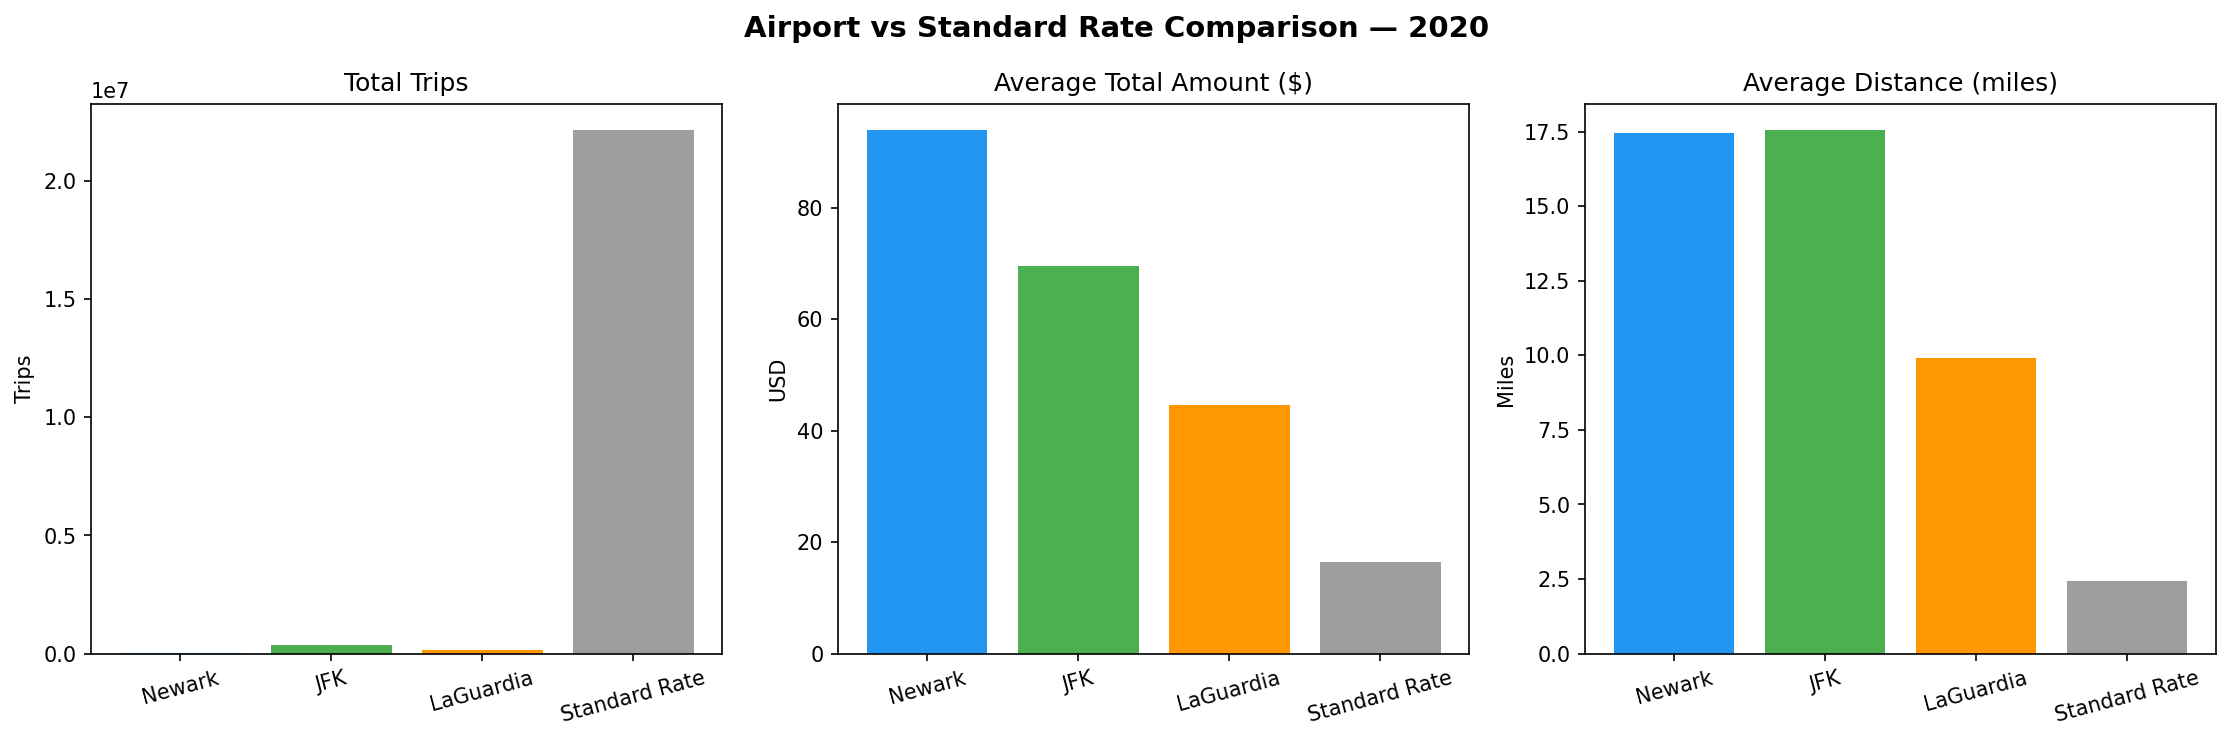

In [56]:
# Comparison between airports and standard rates
airport_comparison = run_query(
    "Airport vs Standard Rate Comparison",
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
            ELSE 'Standard Rate'
        END AS rate_type,
        COUNT(*) AS total_trips,
        ROUND(AVG(total_amount), 2) AS avg_total_amount,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(tip_amount), 2) AS avg_tip
    FROM taxi
    WHERE RatecodeID IN (1, 2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
            ELSE 'Standard Rate'
        END
    ORDER BY avg_total_amount DESC
    """
)

# Visualização
pdf = airport_comparison.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9E9E9E"]

axes[0].bar(pdf["rate_type"], pdf["total_trips"], color=colors)
axes[0].set_title("Total Trips")
axes[0].set_ylabel("Trips")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(pdf["rate_type"], pdf["avg_total_amount"], color=colors)
axes[1].set_title("Average Total Amount ($)")
axes[1].set_ylabel("USD")
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(pdf["rate_type"], pdf["avg_distance"], color=colors)
axes[2].set_title("Average Distance (miles)")
axes[2].set_ylabel("Miles")
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("Airport vs Standard Rate Comparison — 2020", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("airport_comparison.png", dpi=150, bbox_inches="tight")
plt.close()

img = PILImage.open("airport_comparison.png")
display(img)

Running: Monthly Airport Trips 2020


+------------+---------+-----------+
|pickup_month|  airport|total_trips|
+------------+---------+-----------+
|           1|LaGuardia|      60238|
|           1|   Newark|      12060|
|           1|      JFK|     142172|
|           2|      JFK|     126789|
|           2|LaGuardia|      58901|
|           2|   Newark|      11367|
|           3|      JFK|      52428|
|           3|   Newark|       5182|
|           3|LaGuardia|      26272|
|           4|   Newark|        109|
|           4|      JFK|        720|
|           4|LaGuardia|        259|
|           5|      JFK|       1374|
|           5|LaGuardia|        540|
|           5|   Newark|        226|
|           6|      JFK|       4147|
|           6|LaGuardia|       1423|
|           6|   Newark|        412|
|           7|LaGuardia|       1827|
|           7|      JFK|       5652|
+------------+---------+-----------+
only showing top 20 rows

⏱ Monthly Airport Trips 2020 completed in 1.15 seconds



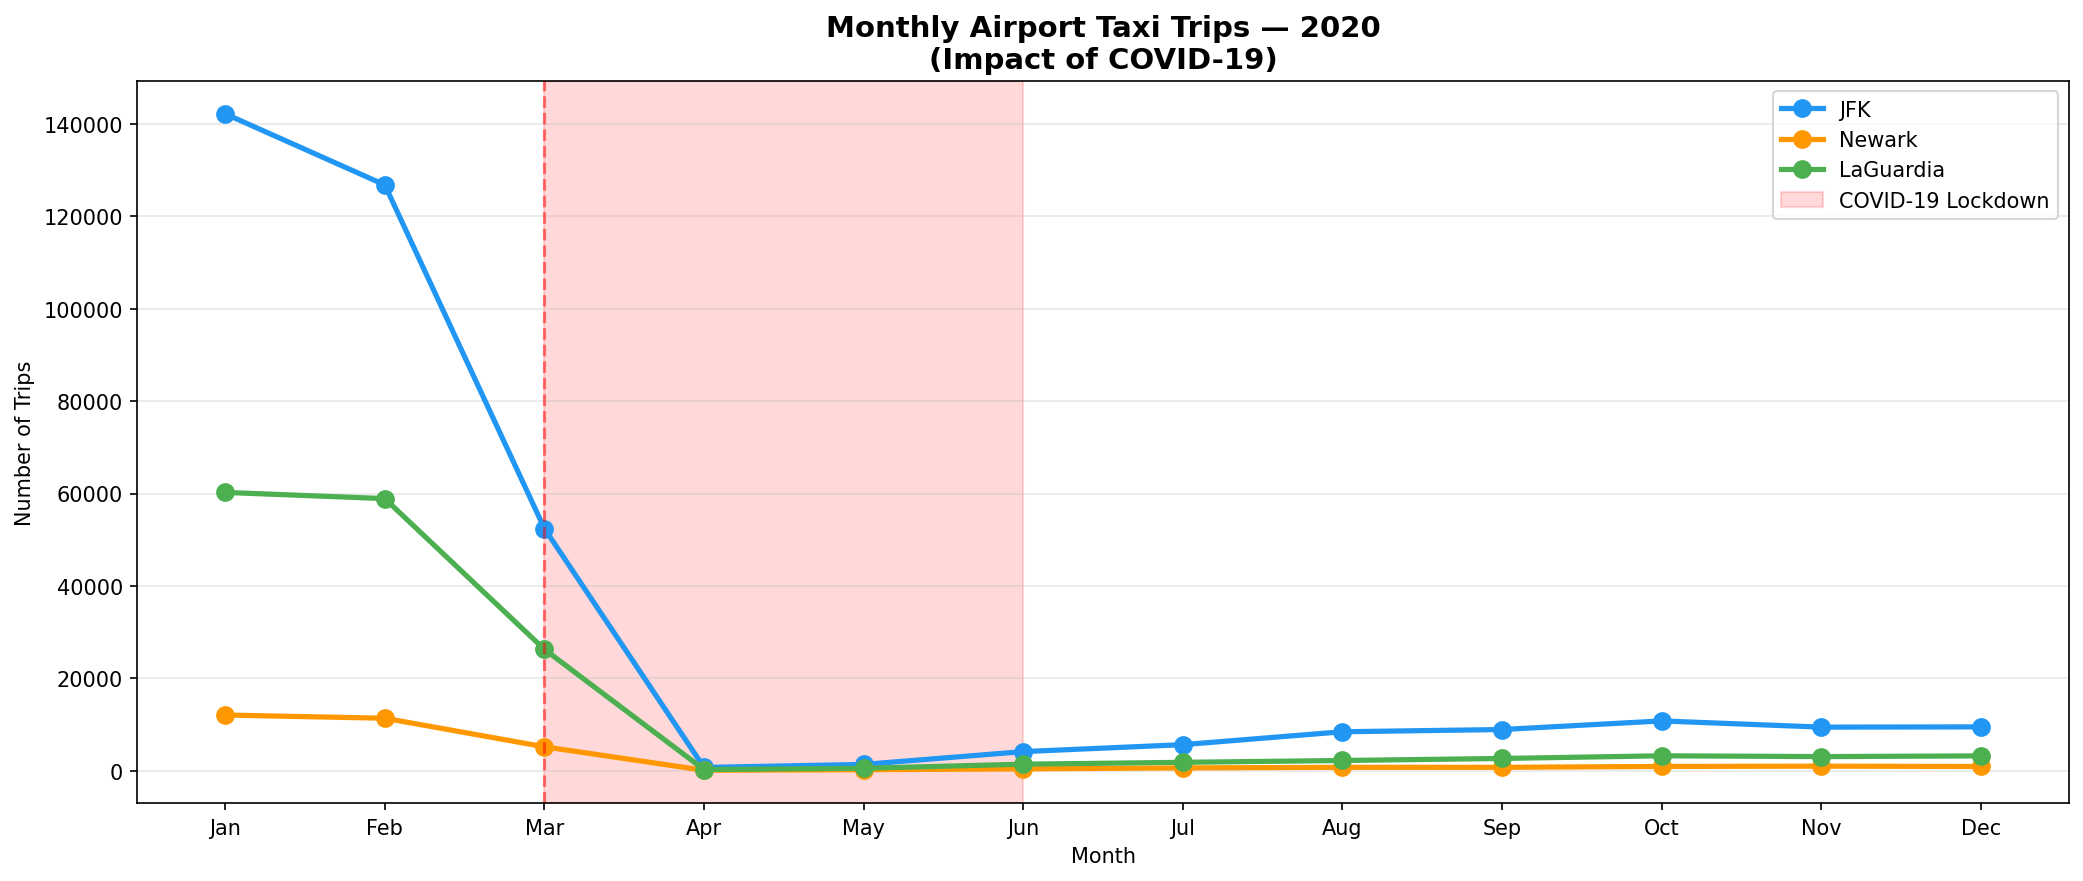

In [ ]:
# Monthly Evolution of Trips to Airports
airport_monthly = run_query(
    "Monthly Airport Trips 2020",
    """
    SELECT
        pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        COUNT(*) AS total_trips
    FROM taxi
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END
    ORDER BY pickup_month
    """
)

pdf = airport_monthly.toPandas()

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(14, 6))

colors = {"JFK": "#2196F3", "Newark": "#FF9800", "LaGuardia": "#4CAF50"}

for airport in ["JFK", "Newark", "LaGuardia"]:
    data = pdf[pdf["airport"] == airport].sort_values("pickup_month")
    ax.plot(data["pickup_month"], data["total_trips"],
            marker="o", linewidth=2.5, markersize=8,
            label=airport, color=colors[airport])

# Marca o lockdown
ax.axvspan(3, 6, alpha=0.15, color="red", label="COVID-19 Lockdown")
ax.axvline(x=3, color="red", linestyle="--", alpha=0.5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("Monthly Airport Taxi Trips — 2020\n(Impact of COVID-19)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Trips")
ax.set_xlabel("Month")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("airport_monthly.png", dpi=150, bbox_inches="tight")
plt.close()

img = PILImage.open("airport_monthly.png")
display(img)

Running: Payment Components by Airport


+---------+-------------+----------+-----------+----------------+---------+-----------------+---------+
|  airport|   total_fare| total_tip|total_tolls|total_congestion|total_mta|total_improvement|    extra|
+---------+-------------+----------+-----------+----------------+---------+-----------------+---------+
|      JFK|1.977569598E7|3320258.56| 1871258.27|        846352.5| 190148.7|         114083.7|572697.13|
|LaGuardia|    5041330.6| 1014141.9|  731415.36|        344575.0|  81581.3|          49134.0|139438.75|
|   Newark|   2312946.48| 379673.03|  511503.68|           515.0|      1.5|          10290.0|  7277.21|
+---------+-------------+----------+-----------+----------------+---------+-----------------+---------+

⏱ Payment Components by Airport completed in 2.14 seconds



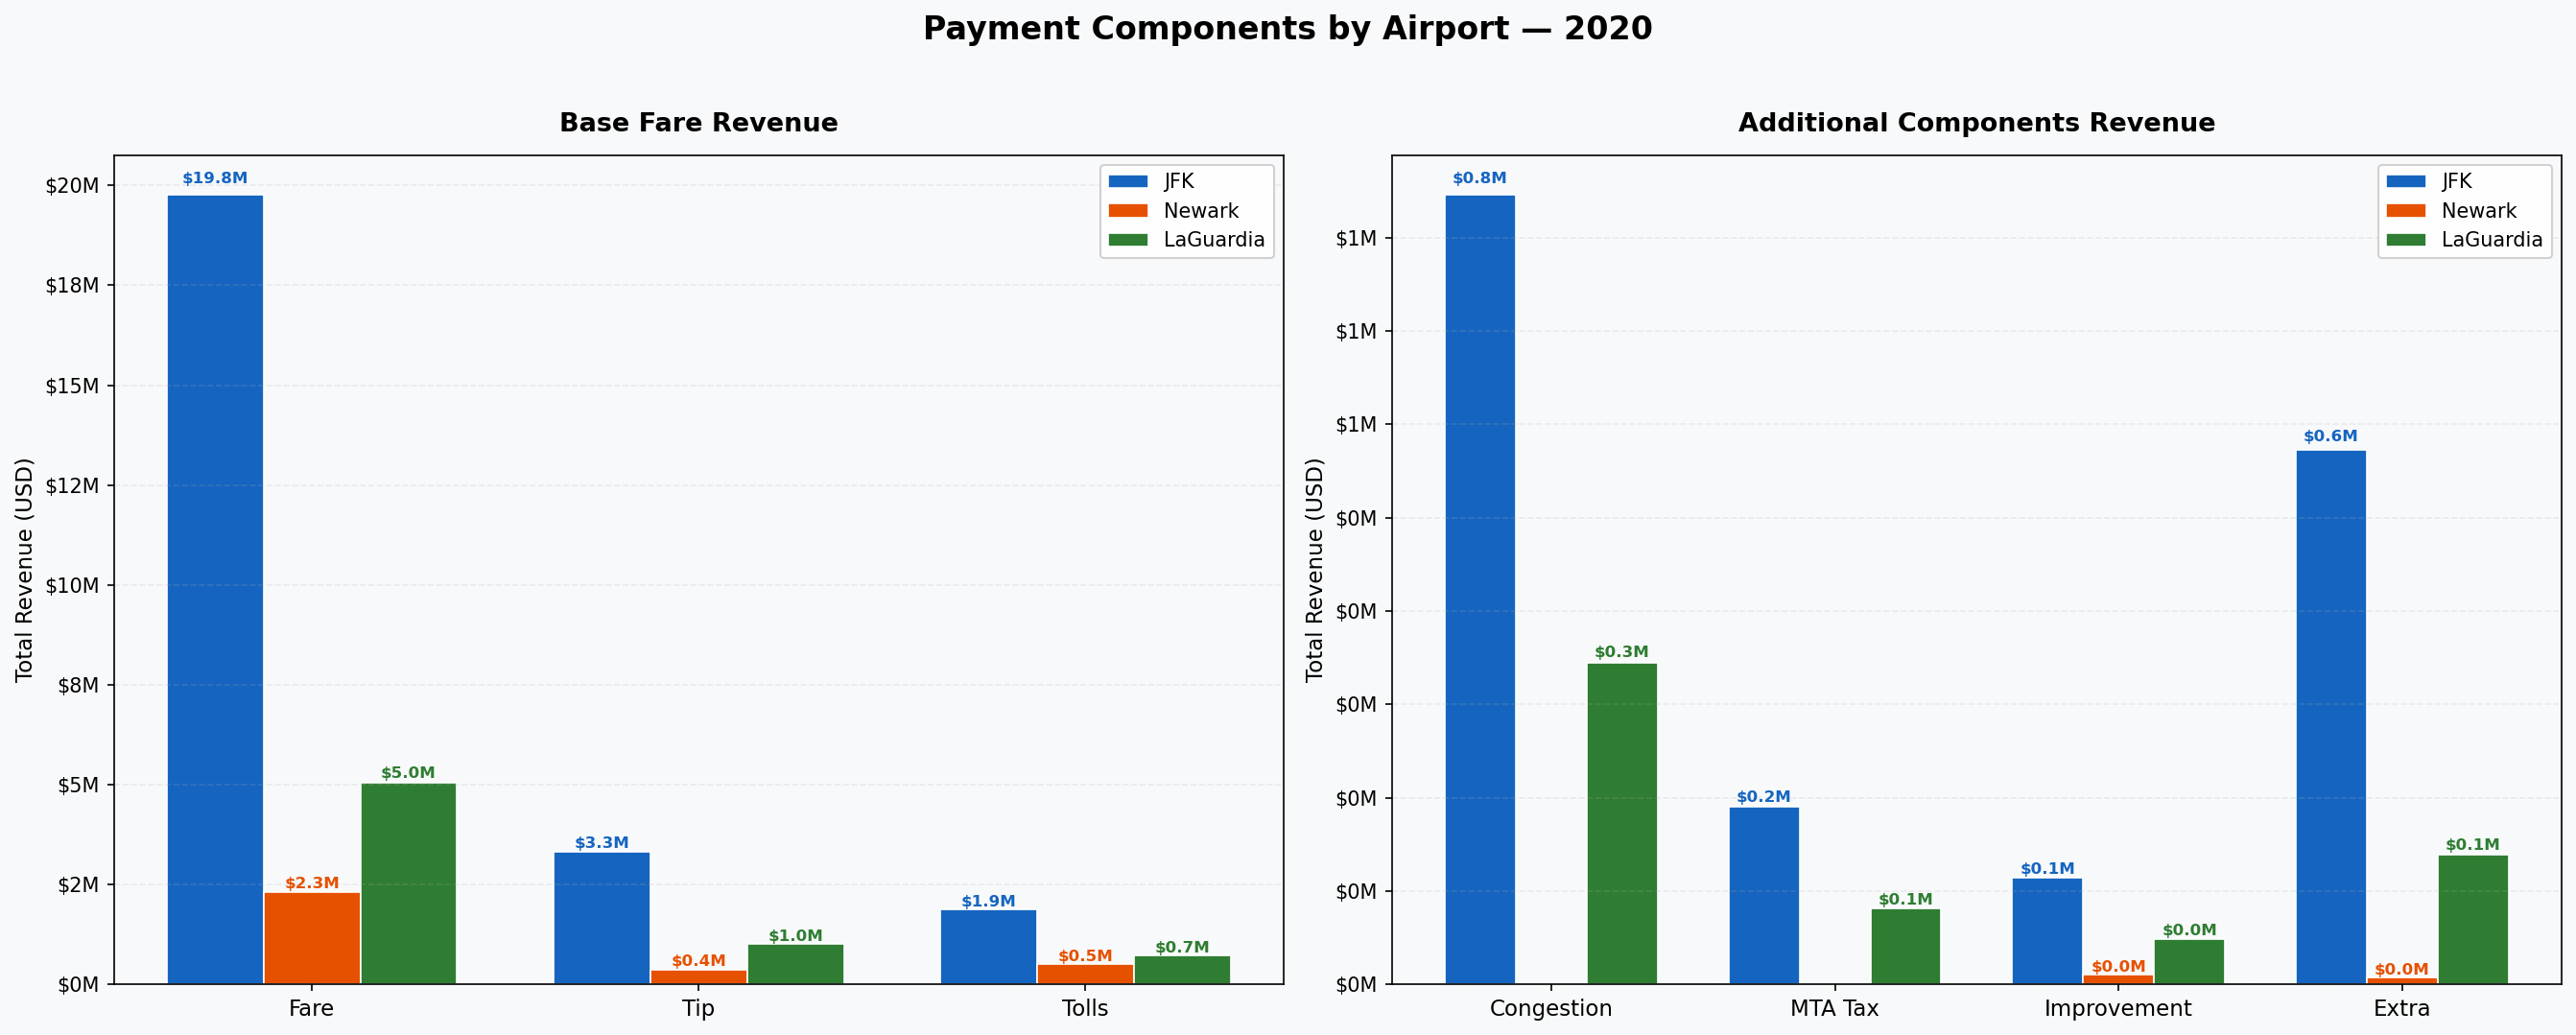

In [ ]:
# Payment Components by airport
payment_components = run_query(
    "Payment Components by Airport",
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        ROUND(SUM(fare_amount), 2) AS total_fare,
        ROUND(SUM(tip_amount), 2) AS total_tip,
        ROUND(SUM(tolls_amount), 2) AS total_tolls,
        ROUND(SUM(congestion_surcharge), 2) AS total_congestion,
        ROUND(SUM(mta_tax), 2) AS total_mta,
        ROUND(SUM(improvement_surcharge), 2) AS total_improvement,
        ROUND(SUM(extra), 2) AS extra
    FROM taxi
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END
    ORDER BY airport
    """
)

pdf = payment_components.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors_airport = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

group1_cols = ["total_fare", "total_tip", "total_tolls"]
group1_labels = ["Fare", "Tip", "Tolls"]

group2_cols = ["total_congestion", "total_mta", "total_improvement", "extra"]
group2_labels = ["Congestion", "MTA Tax", "Improvement", "Extra"]

width = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F9FA")

def plot_components(ax, cols, labels, title):
    ax.set_facecolor("#F8F9FA")
    x = range(len(labels))

    for i, airport in enumerate(airports):
        row = pdf[pdf["airport"] == airport].iloc[0]
        values = [row[c] for c in cols]

        bars = ax.bar([xi + i * width for xi in x],
                      values,
                      width=width,
                      label=airport,
                      color=colors_airport[airport],
                      edgecolor="white",
                      linewidth=0.8)

        for bar, val in zip(bars, values):
            if val > 1000:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + bar.get_height() * 0.01,
                        f"${val/1e6:.1f}M",
                        ha="center", va="bottom",
                        fontsize=8, fontweight="bold",
                        color=colors_airport[airport])

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Total Revenue (USD)", fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

plot_components(ax1, group1_cols, group1_labels, "Base Fare Revenue")
plot_components(ax2, group2_cols, group2_labels, "Additional Components Revenue")

fig.suptitle("Payment Components by Airport — 2020",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("airport_components_bars.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F9FA")
plt.close()

img = PILImage.open("airport_components_bars.png")
display(img)

Running: Airport Trips by Hour and Day of Week


+-----------+------------------+-----------+
|pickup_hour|pickup_day_of_week|total_trips|
+-----------+------------------+-----------+
|          0|                 1|       1071|
|          1|                 1|        397|
|          2|                 1|        207|
|          3|                 1|        416|
|          4|                 1|       1029|
|          5|                 1|       2254|
|          6|                 1|       2998|
|          7|                 1|       3288|
|          8|                 1|       3395|
|          9|                 1|       3223|
|         10|                 1|       3429|
|         11|                 1|       3732|
|         12|                 1|       4553|
|         13|                 1|       5831|
|         14|                 1|       6671|
|         15|                 1|       7116|
|         16|                 1|       6767|
|         17|                 1|       6015|
|         18|                 1|       5430|
|         

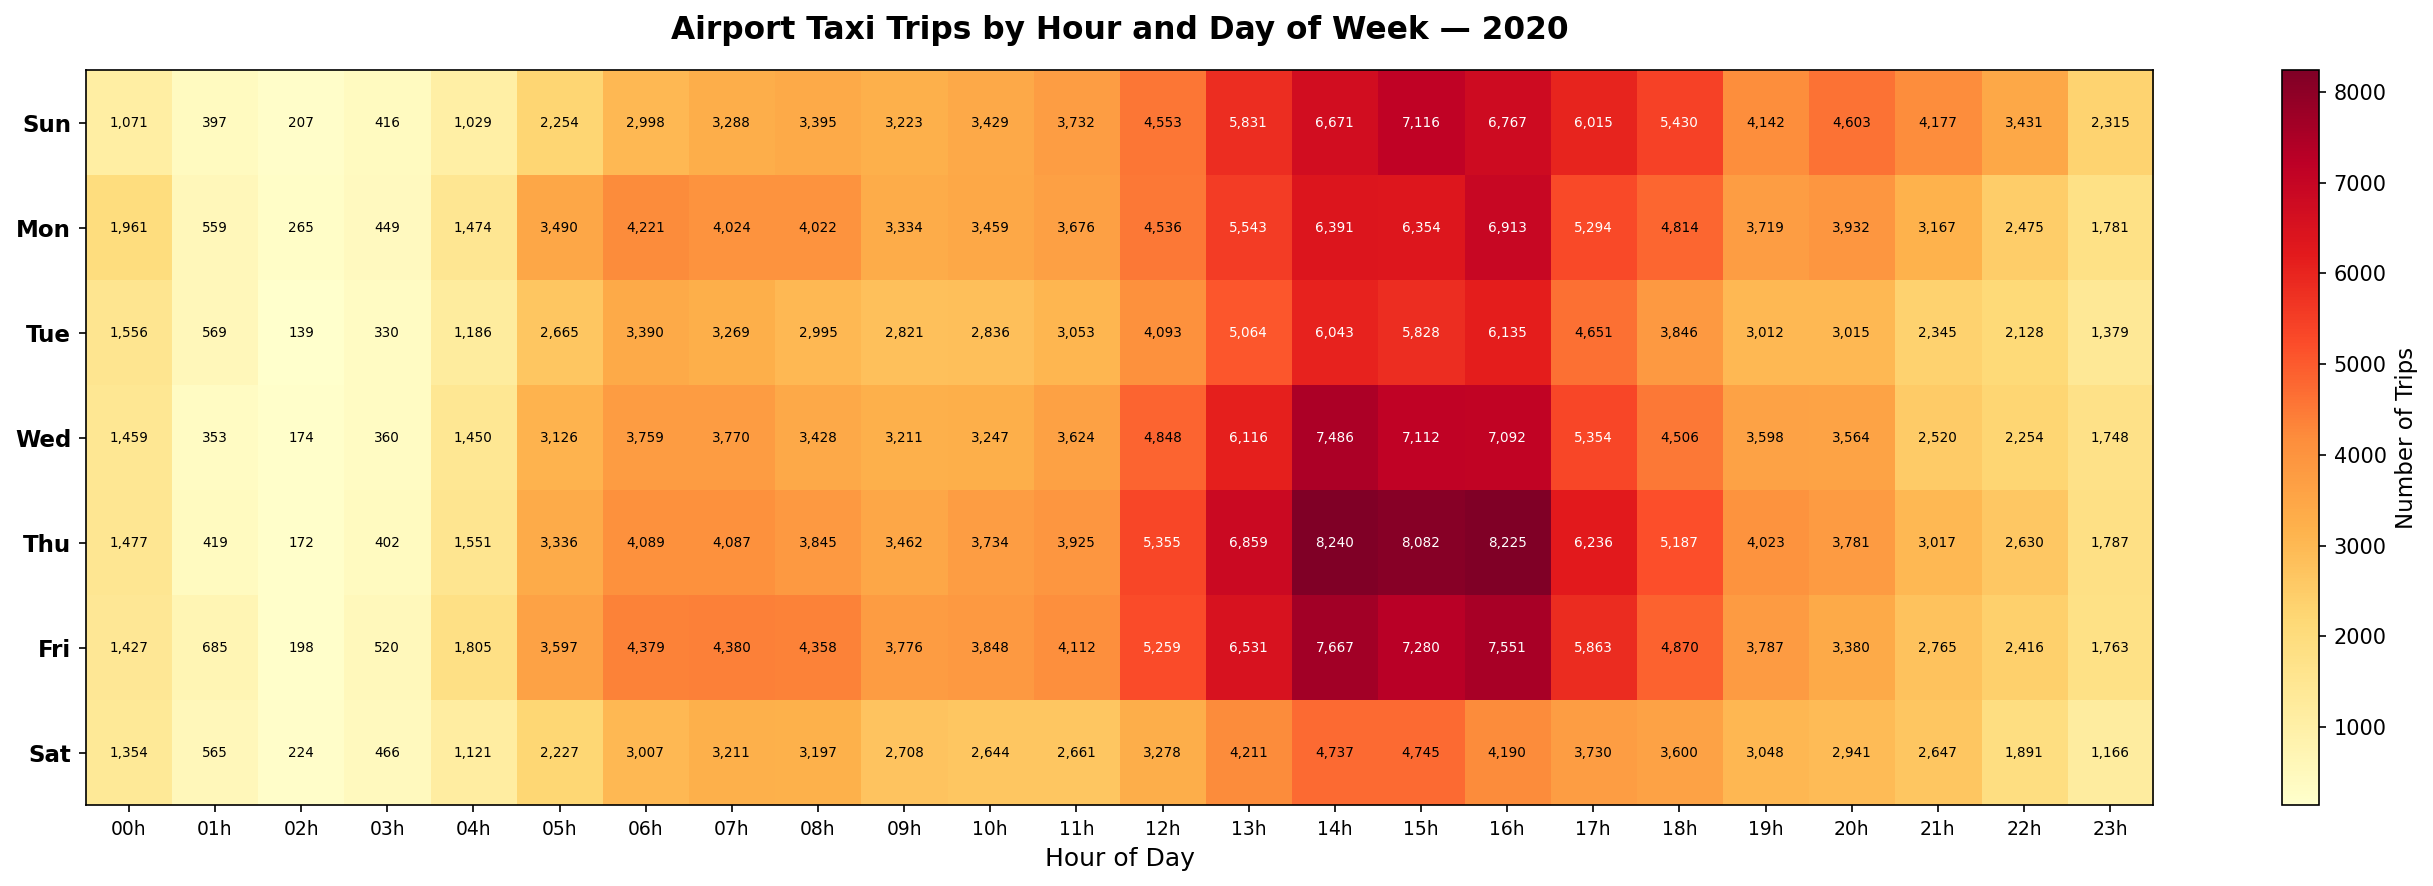

In [ ]:
# Heatmap with trips by hour and day of week
heatmap_data = run_query(
    "Airport Trips by Hour and Day of Week",
    """
    SELECT
        pickup_hour,
        pickup_day_of_week,
        COUNT(*) AS total_trips
    FROM taxi
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY pickup_hour, pickup_day_of_week
    ORDER BY pickup_day_of_week, pickup_hour
    """
)

pdf = heatmap_data.toPandas()

# Pivot para formato matriz
pivot = pdf.pivot(index="pickup_day_of_week",
                  columns="pickup_hour",
                  values="total_trips").fillna(0)

days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
hours = [f"{h:02d}h" for h in range(24)]

fig, ax = plt.subplots(figsize=(18, 6))

im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

# Anotações em cada célula
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{int(val):,}",
                ha="center", va="center",
                fontsize=6.5,
                color="black" if val < pivot.values.max() * 0.6 else "white")

ax.set_xticks(range(24))
ax.set_xticklabels(hours, fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(days, fontsize=11, fontweight="bold")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of Trips", fontsize=11)

ax.set_title("Airport Taxi Trips by Hour and Day of Week — 2020",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Hour of Day", fontsize=12)

plt.tight_layout()
plt.savefig("airport_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()

img = PILImage.open("airport_heatmap.png")
display(img)

Running: Impact of Congestion Surcharge


+--------------------+-----------+--------+---------+------------+------------+
|    congestion_group|total_trips|avg_fare|avg_total|avg_distance|avg_duration|
+--------------------+-----------+--------+---------+------------+------------+
|Without Congestio...|    1694536|   19.94|    24.06|        5.75|       16.38|
|With Congestion S...|   21071967|   11.27|    17.21|        2.54|       12.35|
+--------------------+-----------+--------+---------+------------+------------+

⏱ Impact of Congestion Surcharge completed in 1.40 seconds



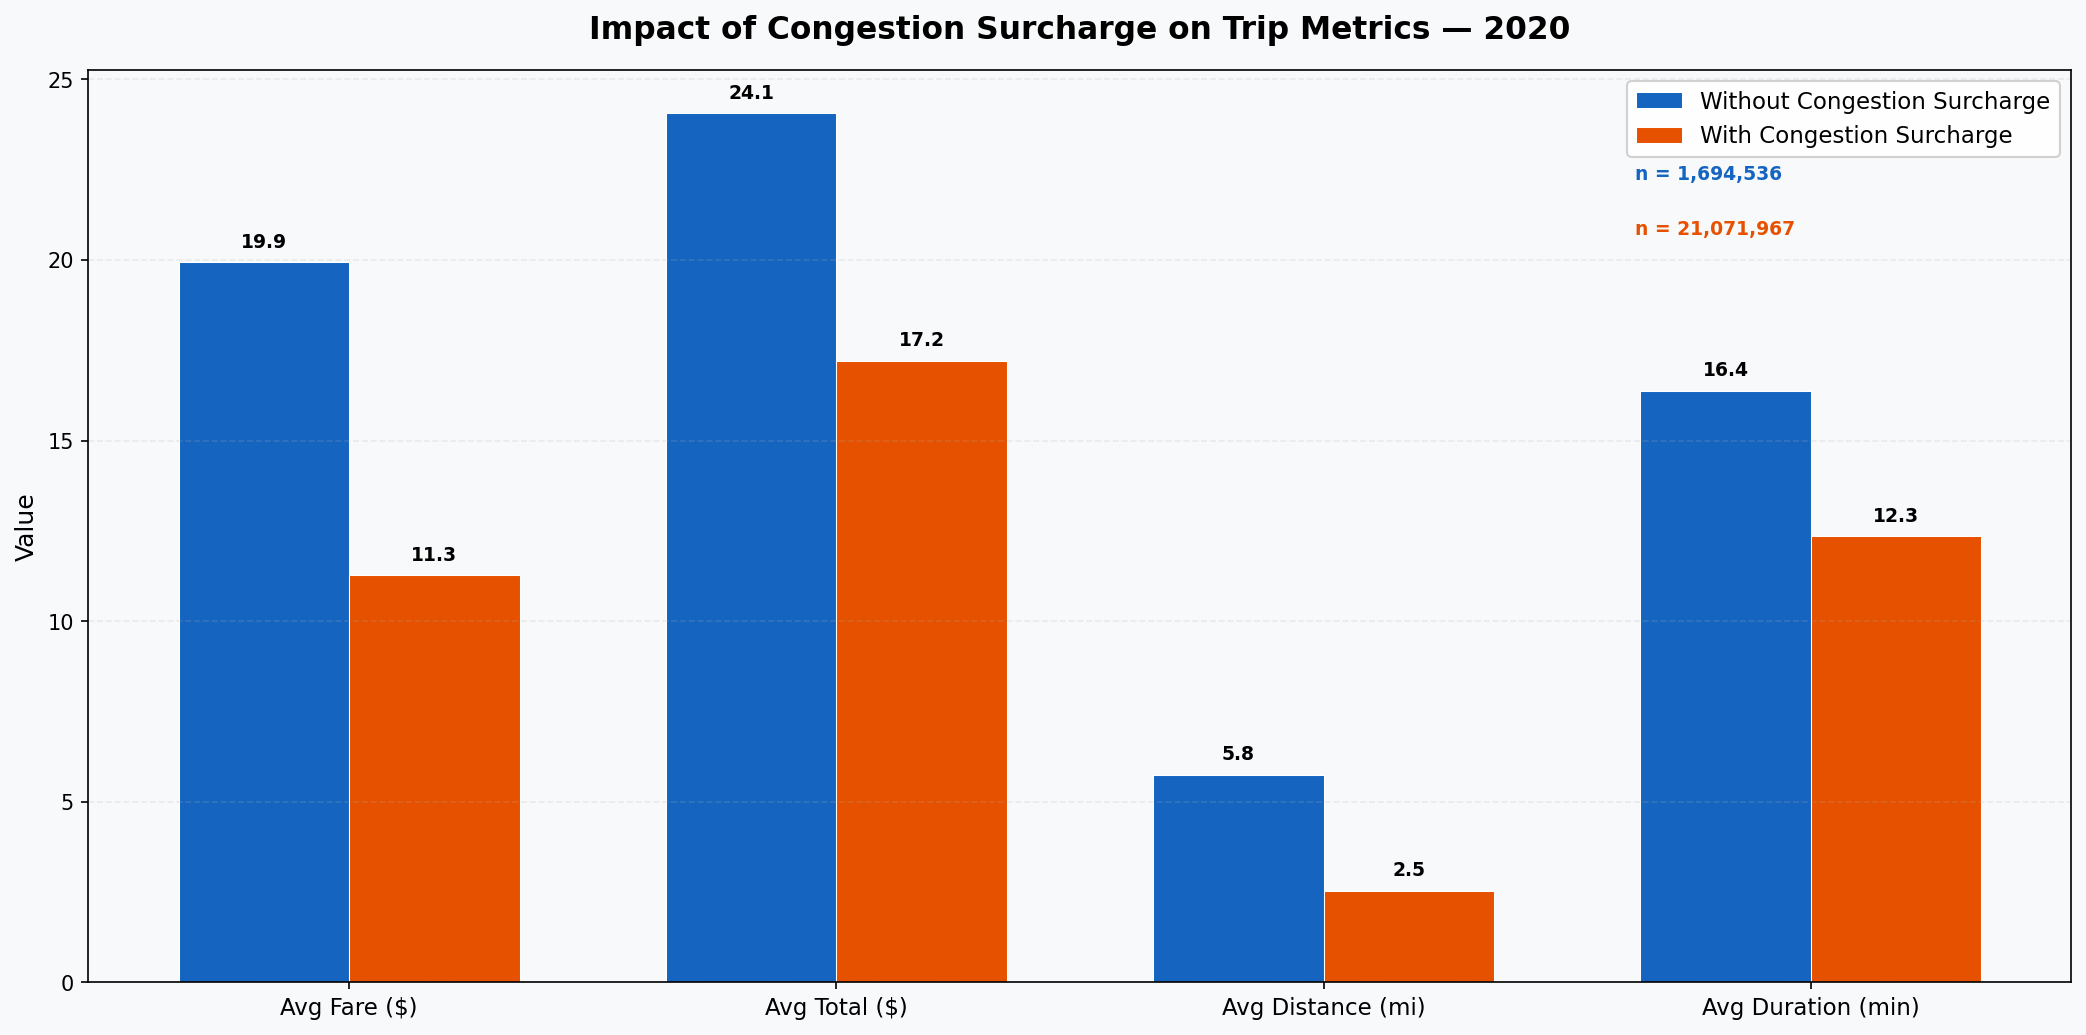

In [ ]:
# Impact of Congestion Surcharge
congestion_impact = run_query(
    "Impact of Congestion Surcharge",
    """
    SELECT
        CASE
            WHEN congestion_surcharge > 0 THEN 'With Congestion Surcharge'
            ELSE 'Without Congestion Surcharge'
        END AS congestion_group,
        COUNT(*) AS total_trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(total_amount), 2) AS avg_total,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(trip_duration), 2) AS avg_duration
    FROM taxi
    GROUP BY
        CASE
            WHEN congestion_surcharge > 0 THEN 'With Congestion Surcharge'
            ELSE 'Without Congestion Surcharge'
        END
    ORDER BY congestion_group DESC
    """
)

pdf = congestion_impact.toPandas()

metrics = ["avg_fare", "avg_total", "avg_distance", "avg_duration"]
labels = ["Avg Fare ($)", "Avg Total ($)", "Avg Distance (mi)", "Avg Duration (min)"]
colors = ["#1565C0", "#E65100"]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(pdf.iterrows()):
    values = [row[m] for m in metrics]
    bars = ax.bar([xi + i * width for xi in x], values,
                  width=width, label=row["congestion_group"],
                  color=colors[i], edgecolor="white", linewidth=0.5)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold")

ax.set_xticks([xi + width / 2 for xi in x])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Impact of Congestion Surcharge on Trip Metrics — 2020",
             fontsize=15, fontweight="bold", pad=15)
ax.set_ylabel("Value", fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

legend = ax.legend(fontsize=11, framealpha=0.9)

for i, (_, row) in enumerate(pdf.iterrows()):
    ax.annotate(f"n = {int(row['total_trips']):,}",
                xy=(0, 0), xycoords='axes fraction',
                xytext=(0.78, 0.88 - i * 0.06),
                textcoords='axes fraction',
                fontsize=9, color=colors[i], fontweight="bold")

plt.tight_layout()
plt.savefig("congestion_impact.png", dpi=150, bbox_inches="tight")
plt.close()

img = PILImage.open("congestion_impact.png")
display(img)

Running: Distance vs Total Amount by Airport
+---------+-------------+------------+----------+
|  airport|trip_distance|total_amount|tip_amount|
+---------+-------------+------------+----------+
|      JFK|        16.62|       61.42|       0.0|
|      JFK|         17.2|       68.42|       7.0|
|      JFK|         13.6|       61.42|       0.0|
|      JFK|         19.8|       73.62|      14.7|
|      JFK|        18.64|       76.78|     15.36|
|      JFK|         20.6|       68.92|       7.5|
|LaGuardia|        12.42|       49.92|       5.0|
|LaGuardia|         10.1|       46.07|      7.65|
|      JFK|        17.34|       62.53|      1.11|
|      JFK|        12.17|       66.36|     11.06|
|      JFK|        18.23|       61.42|       0.0|
|      JFK|        17.72|        73.7|     12.28|
|      JFK|        19.72|        70.7|     11.78|
|      JFK|         18.2|       61.42|       0.0|
|LaGuardia|         11.8|       43.29|      9.99|
|      JFK|        20.44|        55.3|       0.0|
|    

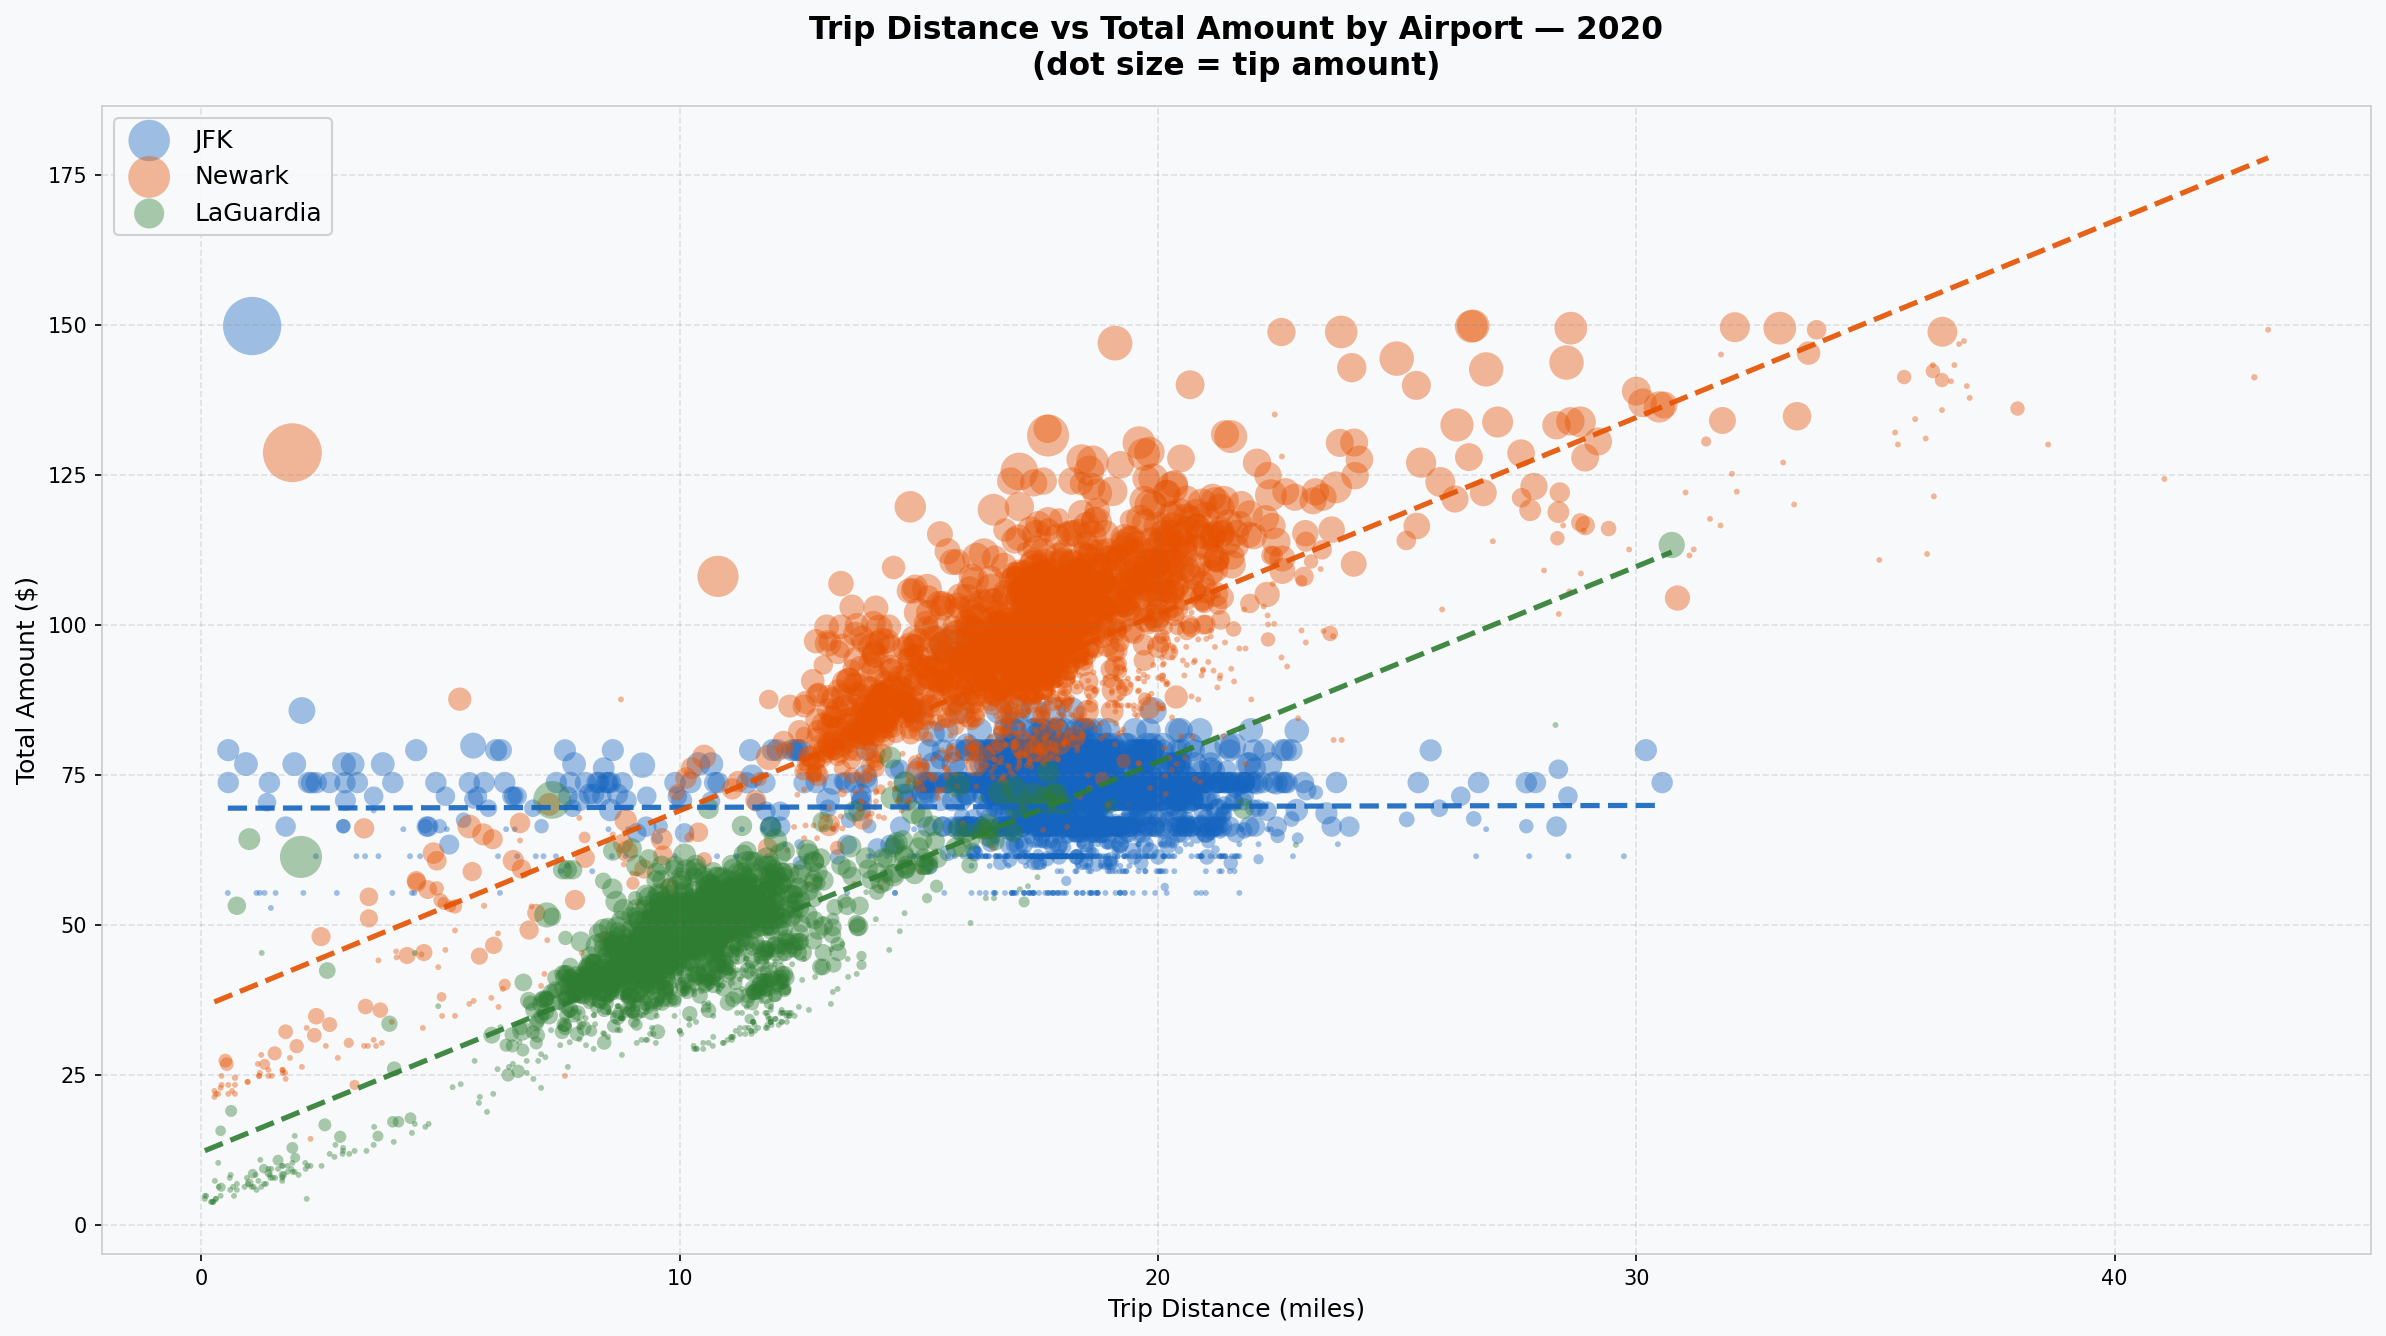

In [ ]:
# Trip distance and total amount by airport
scatter_data = run_query(
    "Distance vs Total Amount by Airport",
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        trip_distance,
        total_amount,
        tip_amount
    FROM taxi
    WHERE (RatecodeID IN (2, 3) OR DOLocationID = 138)
    AND trip_distance > 0
    AND trip_distance < 50
    AND total_amount < 150
    """
)

pdf = scatter_data.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for airport in airports:
    data = pdf[pdf["airport"] == airport]

    sample = data.sample(min(2000, len(data)), random_state=42)

    sizes = (sample["tip_amount"] + 1) * 8

    ax.scatter(sample["trip_distance"], sample["total_amount"],
               c=colors[airport], s=sizes, alpha=0.4,
               label=airport, edgecolors="none")

    z = np.polyfit(sample["trip_distance"], sample["total_amount"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample["trip_distance"].min(),
                         sample["trip_distance"].max(), 100)
    ax.plot(x_line, p(x_line), color=colors[airport],
            linewidth=2.5, linestyle="--", alpha=0.9)

ax.set_title("Trip Distance vs Total Amount by Airport — 2020\n(dot size = tip amount)",
             fontsize=15, fontweight="bold", color="black", pad=15)
ax.set_xlabel("Trip Distance (miles)", fontsize=12, color="black")
ax.set_ylabel("Total Amount ($)", fontsize=12, color="black")
ax.tick_params(colors="black")
ax.spines[:].set_color("#CCCCCC")
ax.grid(alpha=0.2, color="gray", linestyle="--")

legend = ax.legend(fontsize=12, framealpha=0.9,
                   facecolor="#F8F9FA")
plt.setp(legend.get_texts(), color="black")

plt.tight_layout()
plt.savefig("airport_scatter.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F9FA")
plt.close()

img = PILImage.open("airport_scatter.png")
display(img)

Running: Payment Methods by Airport


+---------+--------------+-----------+
|  airport|payment_method|total_trips|
+---------+--------------+-----------+
|      JFK|   Credit Card|     303618|
|      JFK|          Cash|      74883|
|      JFK|     No Charge|       1313|
|      JFK|       Dispute|        561|
|LaGuardia|   Credit Card|     132602|
|LaGuardia|          Cash|      30377|
|LaGuardia|     No Charge|        670|
|LaGuardia|       Dispute|        218|
|   Newark|   Credit Card|      26745|
|   Newark|          Cash|       7264|
|   Newark|     No Charge|        211|
|   Newark|       Dispute|         95|
+---------+--------------+-----------+

⏱ Payment Methods by Airport completed in 0.99 seconds



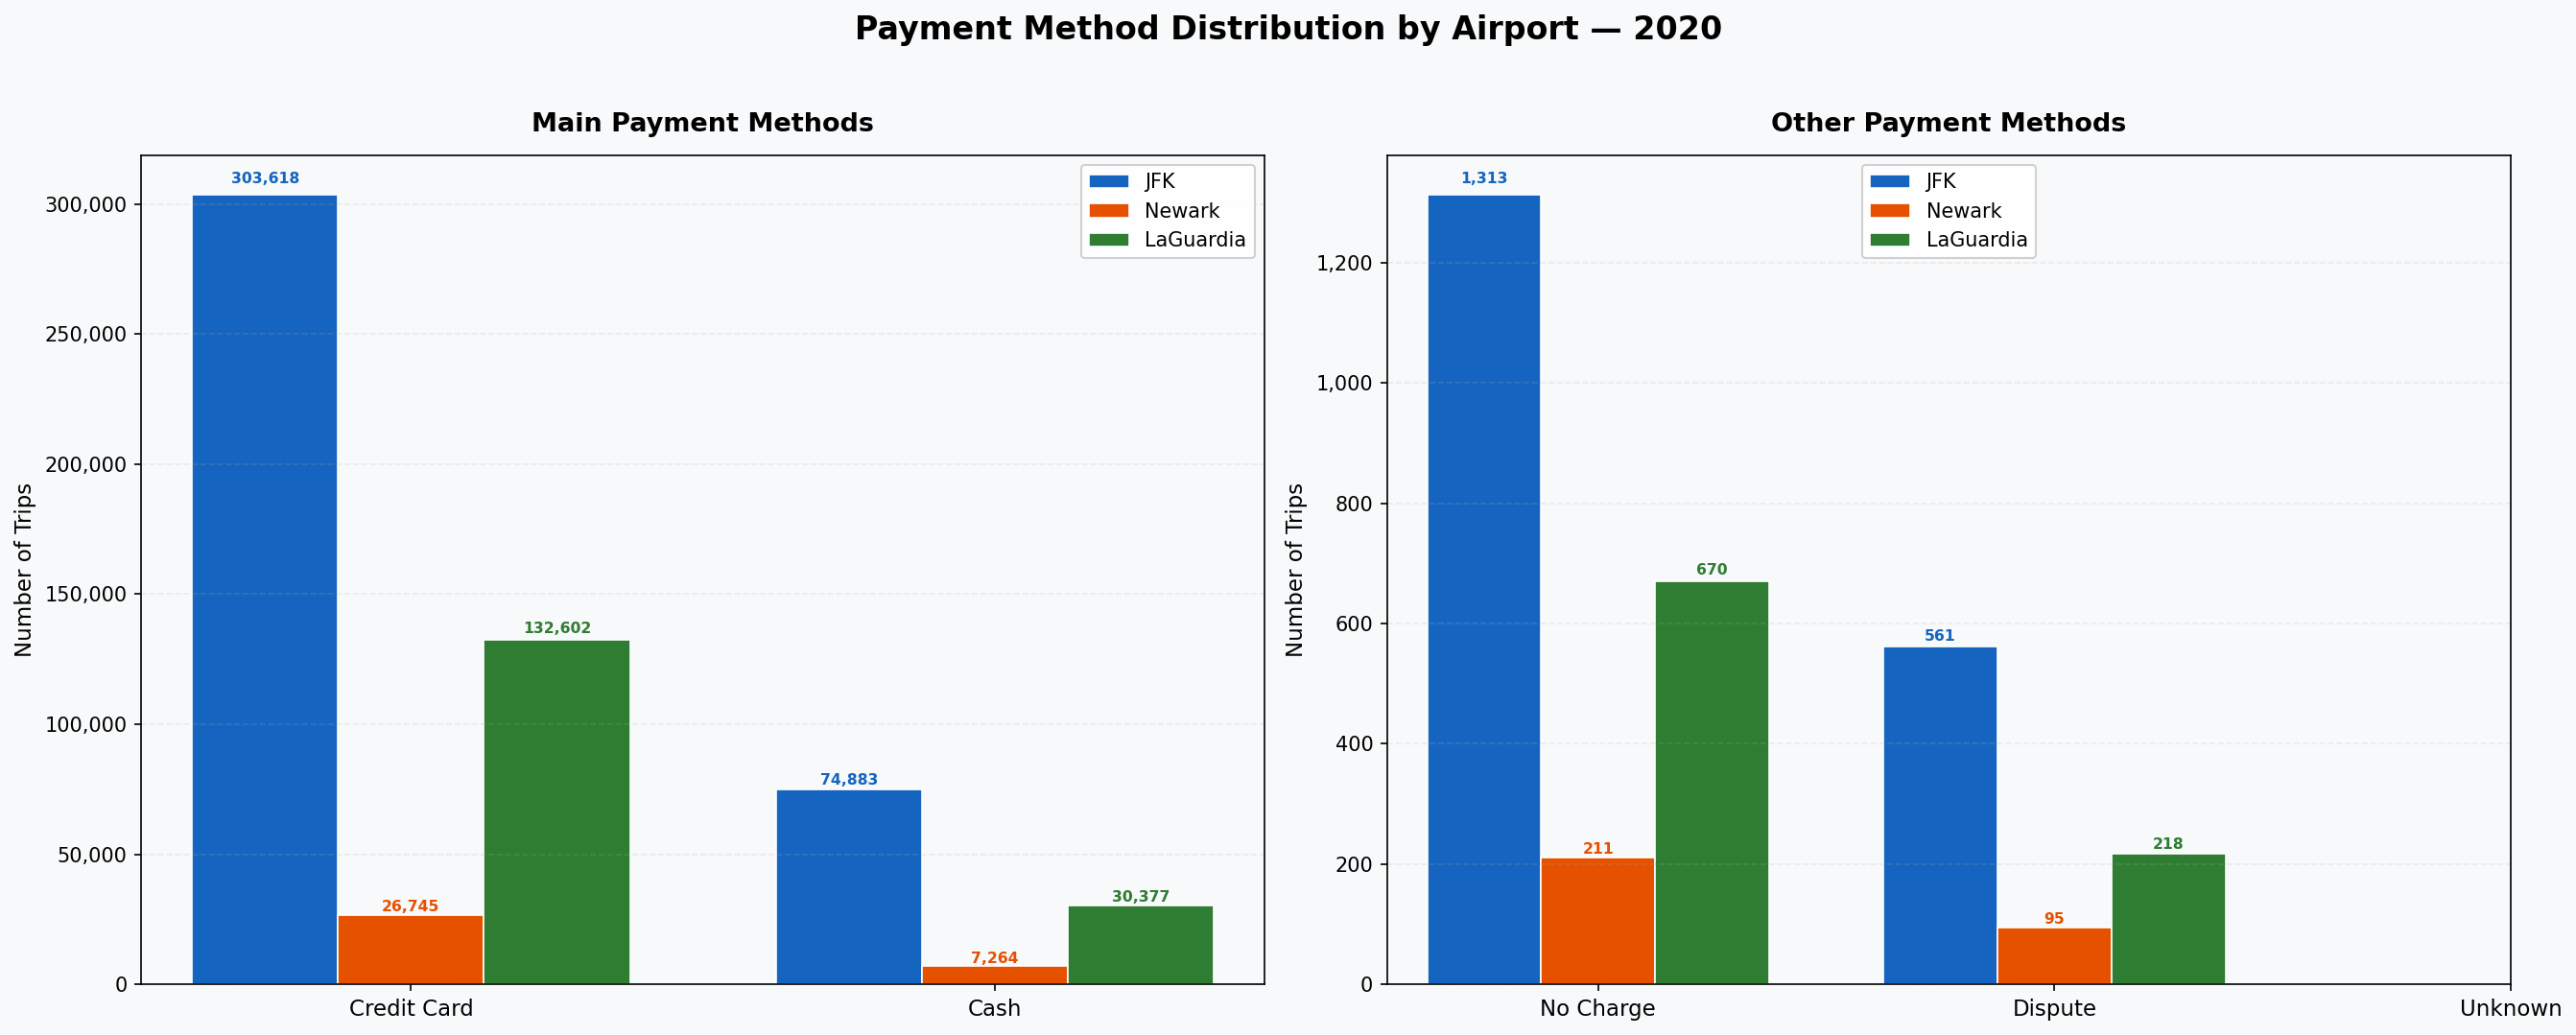

In [ ]:
# Distribution of Payment Methods by Airport
payment_pie = run_query(
    "Payment Methods by Airport",
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        CASE payment_type
            WHEN 1 THEN 'Credit Card'
            WHEN 2 THEN 'Cash'
            WHEN 3 THEN 'No Charge'
            WHEN 4 THEN 'Dispute'
            WHEN 5 THEN 'Unknown'
        END AS payment_method,
        COUNT(*) AS total_trips
    FROM taxi
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END,
        CASE payment_type
            WHEN 1 THEN 'Credit Card'
            WHEN 2 THEN 'Cash'
            WHEN 3 THEN 'No Charge'
            WHEN 4 THEN 'Dispute'
            WHEN 5 THEN 'Unknown'
        END
    ORDER BY airport, total_trips DESC
    """
)

pdf = payment_pie.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

pivot = pdf.pivot(index="payment_method", columns="airport", values="total_trips").fillna(0)

# Separar em dois grupos
group1 = pivot.reindex(["Credit Card", "Cash"]).sort_values("JFK", ascending=False)
group2 = pivot.reindex(["No Charge", "Dispute", "Unknown"]).sort_values("JFK", ascending=False)

width = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F9FA")

def plot_group(ax, data, title):
    ax.set_facecolor("#F8F9FA")
    x = range(len(data.index))

    for i, airport in enumerate(airports):
        bars = ax.bar([xi + i * width for xi in x],
                      data[airport],
                      width=width,
                      label=airport,
                      color=colors[airport],
                      edgecolor="white",
                      linewidth=0.8)

        for bar in bars:
            val = bar.get_height()
            if val > 10:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + val * 0.01,
                        f"{int(val):,}",
                        ha="center", va="bottom",
                        fontsize=7.5, fontweight="bold",
                        color=colors[airport])

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(data.index, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Number of Trips", fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plot_group(ax1, group1, "Main Payment Methods")
plot_group(ax2, group2, "Other Payment Methods")

fig.suptitle("Payment Method Distribution by Airport — 2020",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("payment_bars.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F9FA")
plt.close()

img = PILImage.open("payment_bars.png")
display(img)

In [ ]:
# Passenger Count by Airport
passenger_airport = run_query(
    "Passenger Count by Airport",
    """
    SELECT
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        passenger_count,
        COUNT(*) AS total_trips,
        ROUND(AVG(total_amount), 2) AS avg_total,
        ROUND(AVG(tip_amount), 2) AS avg_tip
    FROM taxi
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END,
        passenger_count
    ORDER BY airport, passenger_count
    """
)

pdf = passenger_airport.toPandas()

airports = ["JFK", "Newark", "LaGuardia"]
colors_airport = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor("#F8F9FA")

Running: Passenger Count by Airport


+---------+---------------+-----------+---------+-------+
|  airport|passenger_count|total_trips|avg_total|avg_tip|
+---------+---------------+-----------+---------+-------+
|      JFK|            1.0|     258536|     69.7|   8.96|
|      JFK|            2.0|      77018|    69.18|   8.22|
|      JFK|            3.0|      16188|    69.05|   7.96|
|      JFK|            4.0|       7857|    68.35|   7.25|
|      JFK|            5.0|      12068|    69.78|   8.94|
|      JFK|            6.0|       8708|    69.53|   8.81|
|LaGuardia|            1.0|     122096|    44.35|   6.22|
|LaGuardia|            2.0|      23811|    45.12|   6.08|
|LaGuardia|            3.0|       6041|    45.24|    6.0|
|LaGuardia|            4.0|       2759|    45.21|   5.72|
|LaGuardia|            5.0|       5431|     44.8|   6.31|
|LaGuardia|            6.0|       3729|    44.66|   6.23|
|   Newark|            1.0|      23663|    93.61|  11.28|
|   Newark|            2.0|       5837|    94.49|  10.44|
|   Newark|   

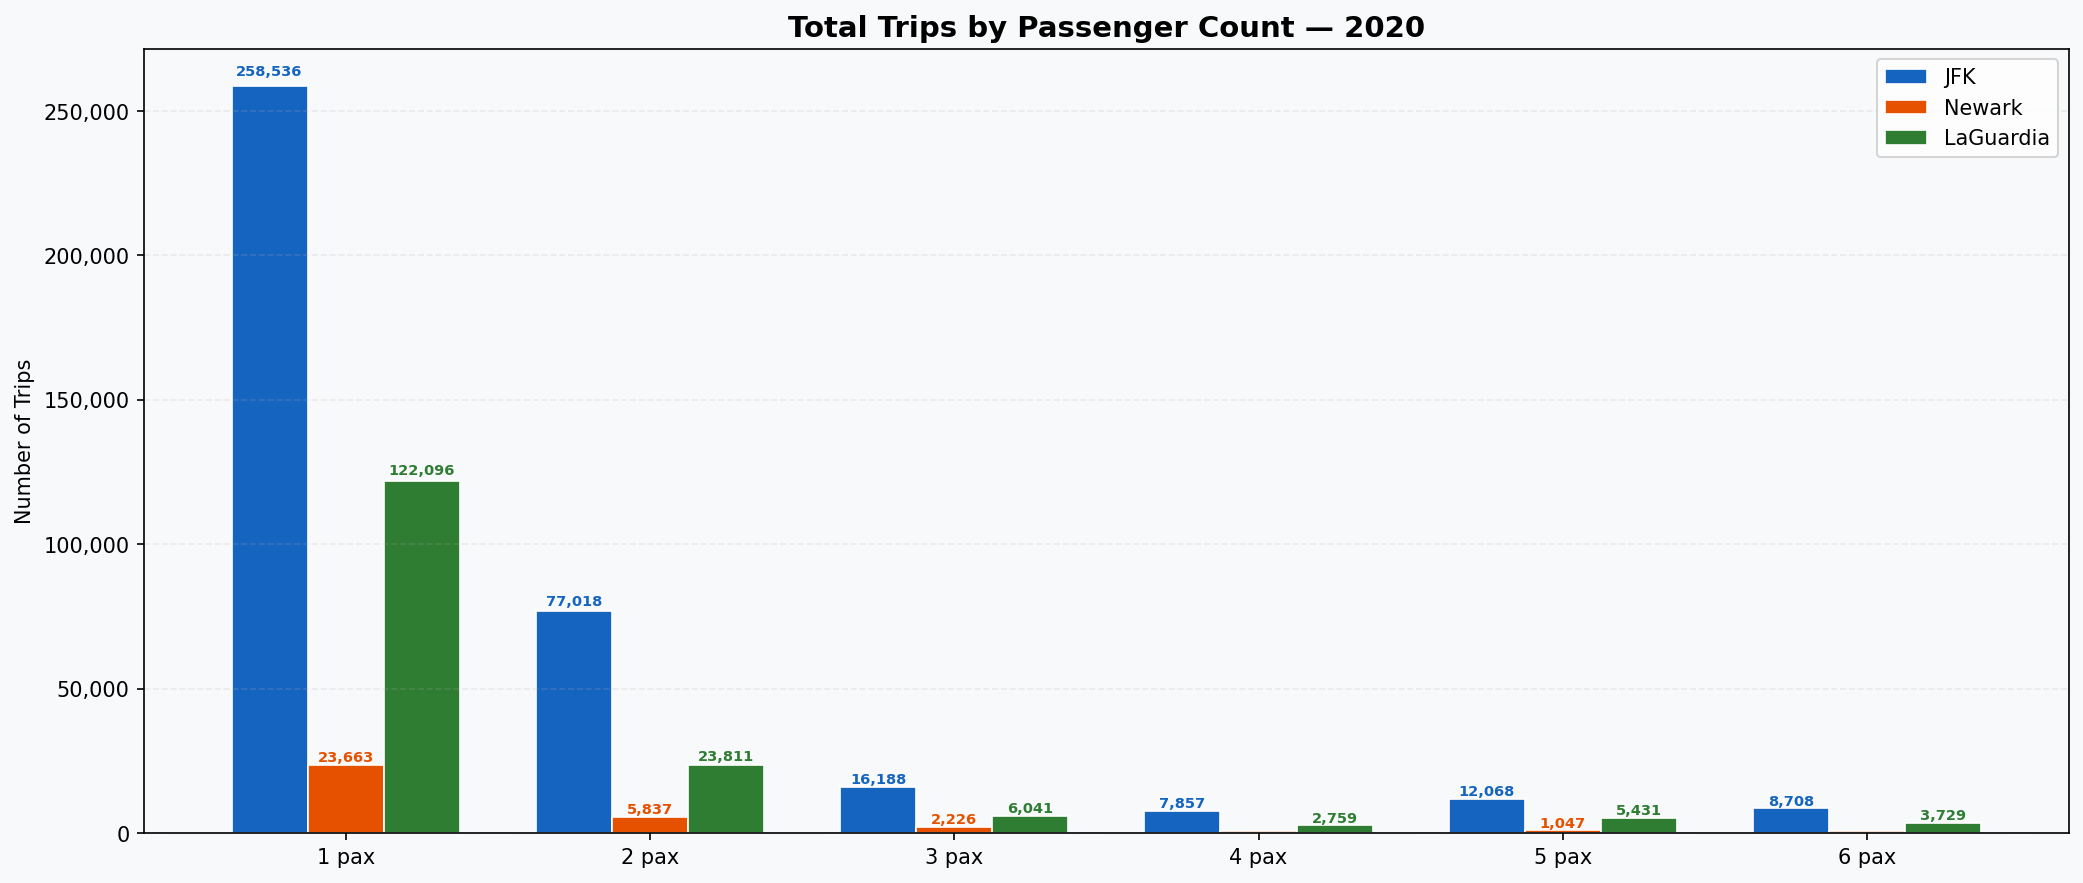

In [ ]:
# Total Trips by Passenger Count and Airport
pivot_trips = pdf.pivot(index="passenger_count", columns="airport",
                         values="total_trips").fillna(0)
x = range(len(pivot_trips.index))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for i, airport in enumerate(airports):
    bars = ax.bar([xi + i * width for xi in x],
                   pivot_trips[airport],
                   width=width, label=airport,
                   color=colors_airport[airport],
                   edgecolor="white", linewidth=0.8)
    for bar in bars:
        val = bar.get_height()
        if val > 1000:
            ax.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + val * 0.01,
                     f"{int(val):,}",
                     ha="center", va="bottom",
                     fontsize=7, fontweight="bold",
                     color=colors_airport[airport])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels([f"{int(p)} pax" for p in pivot_trips.index], fontsize=10)
ax.set_title("Total Trips by Passenger Count — 2020", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Trips")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("pax_trips.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.close()

img = PILImage.open("pax_trips.png")
display(img)

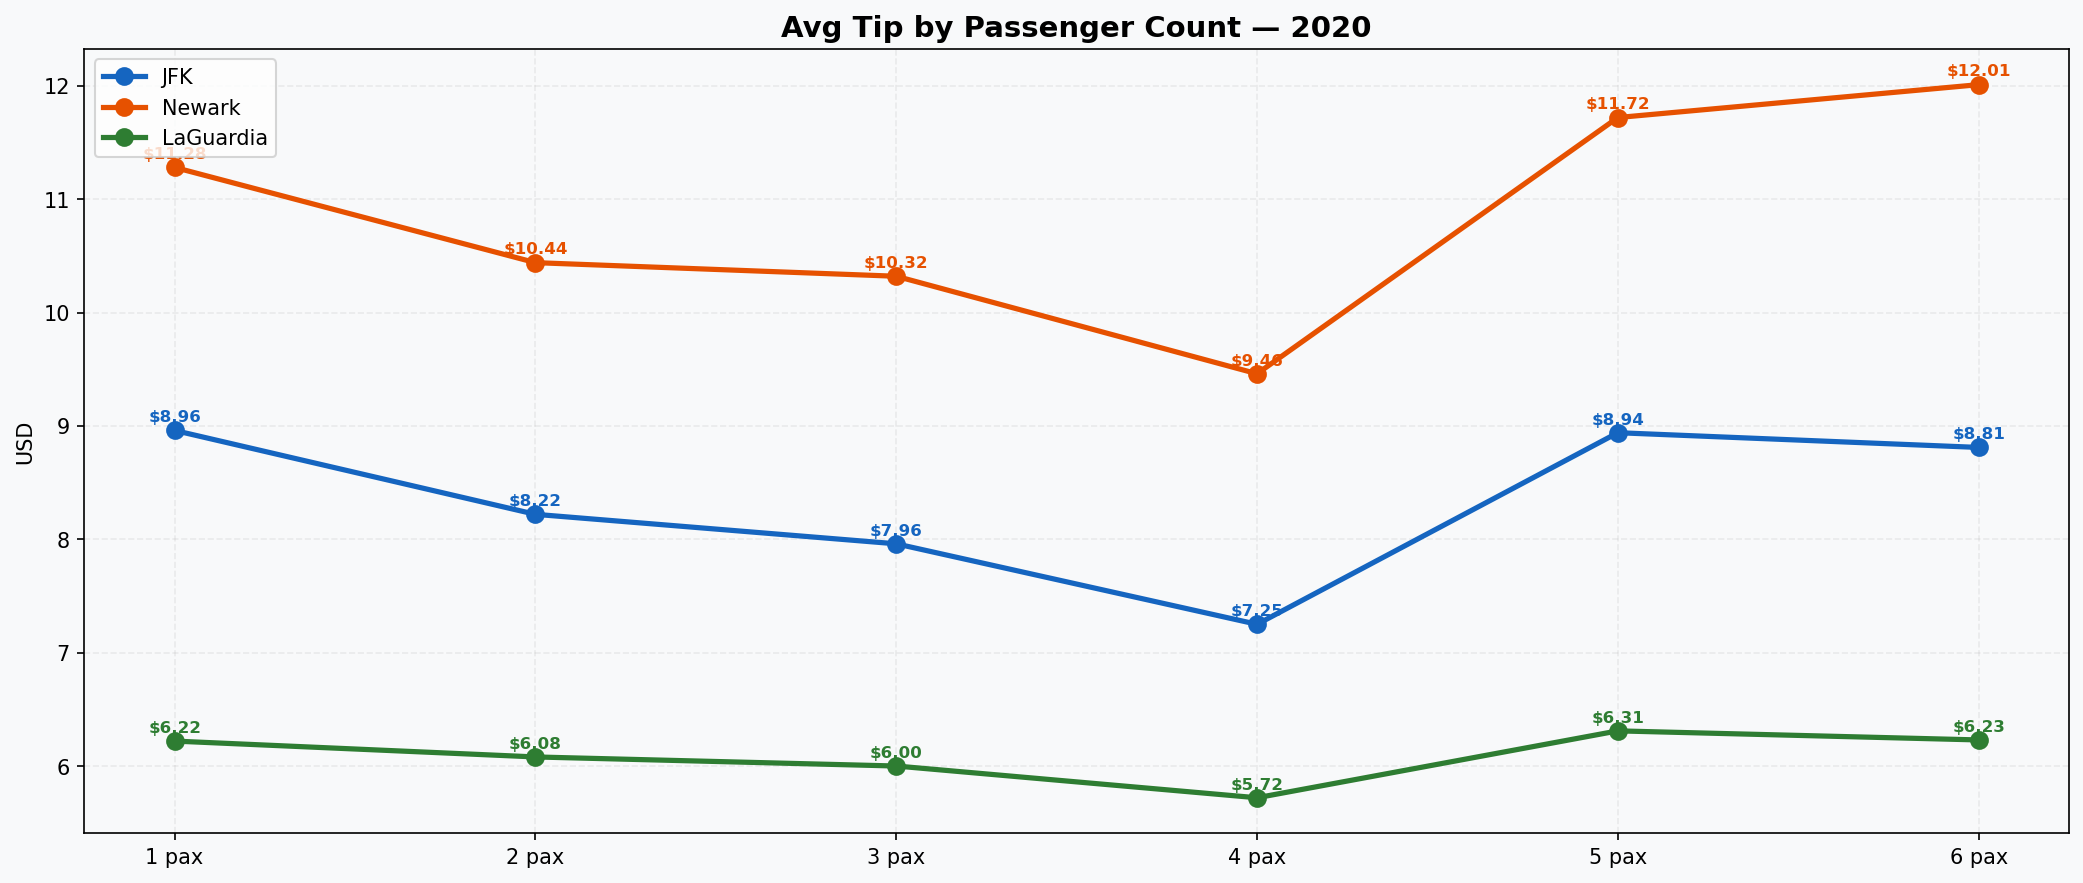

In [ ]:
# Avg Tip by Passenger Count and Airport
pivot_tip = pdf.pivot(index="passenger_count", columns="airport",
                       values="avg_tip").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for airport in airports:
    ax.plot(pivot_tip.index, pivot_tip[airport],
             marker="o", linewidth=2.5, markersize=8,
             label=airport, color=colors_airport[airport])
    for x, y in zip(pivot_tip.index, pivot_tip[airport]):
        ax.text(x, y + 0.05, f"${y:.2f}",
                ha="center", va="bottom",
                fontsize=8, fontweight="bold",
                color=colors_airport[airport])

ax.set_xticks(pivot_tip.index)
ax.set_xticklabels([f"{int(p)} pax" for p in pivot_tip.index], fontsize=10)
ax.set_title("Avg Tip by Passenger Count — 2020", fontsize=14, fontweight="bold")
ax.set_ylabel("USD")
ax.legend(fontsize=10)
ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("pax_tip.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.close()

img = PILImage.open("pax_tip.png")
display(img)

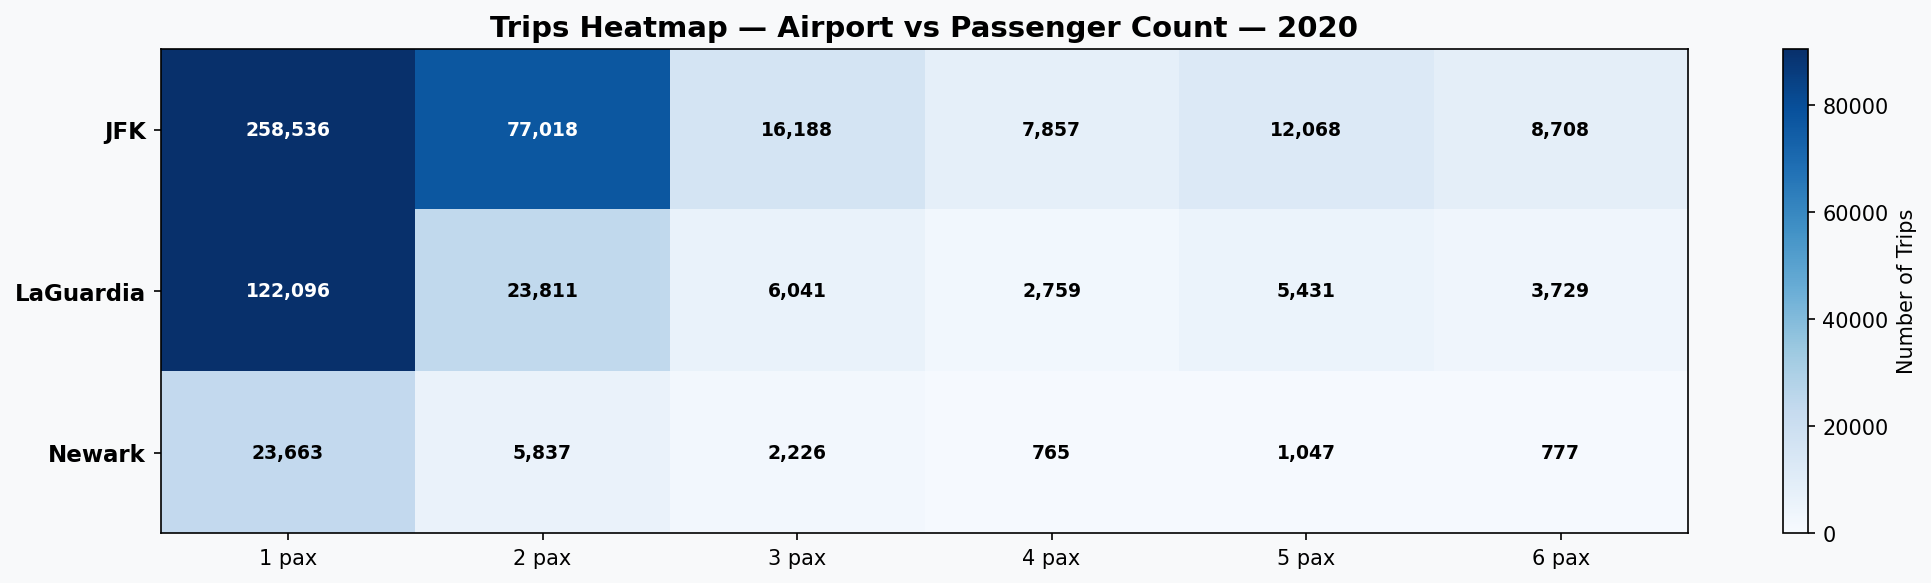

In [96]:
# Heatmap trips by passenger count and airport
pivot_heat = pdf.pivot(index="airport", columns="passenger_count",
                        values="total_trips").fillna(0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

vmax = np.percentile(pivot_heat.values, 90)

im = ax.imshow(pivot_heat.values, cmap="Blues", aspect="auto",
               vmin=0, vmax=vmax)

for i in range(len(pivot_heat.index)):
    for j in range(len(pivot_heat.columns)):
        val = pivot_heat.values[i, j]
        ax.text(j, i, f"{int(val):,}",
                 ha="center", va="center",
                 fontsize=9, fontweight="bold",
                 color="white" if val > 70000 else "black")

ax.set_xticks(range(len(pivot_heat.columns)))
ax.set_xticklabels([f"{int(p)} pax" for p in pivot_heat.columns], fontsize=10)
ax.set_yticks(range(len(pivot_heat.index)))
ax.set_yticklabels(pivot_heat.index, fontsize=11, fontweight="bold")
ax.set_title("Trips Heatmap — Airport vs Passenger Count — 2020",
              fontsize=14, fontweight="bold")
plt.colorbar(im, ax=ax).set_label("Number of Trips")

plt.tight_layout()
plt.savefig("pax_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.close()

img = PILImage.open("pax_heatmap.png")
display(img)

Running: Monthly Average Revenue by Airport


+------------+---------+-----------+--------+-------+
|pickup_month|  airport|avg_revenue|avg_fare|avg_tip|
+------------+---------+-----------+--------+-------+
|           1|LaGuardia|      44.95|   30.99|   6.29|
|           1|   Newark|      93.94|   67.28|   11.1|
|           1|      JFK|      69.71|   51.99|   8.82|
|           2|      JFK|      69.74|   51.99|   8.83|
|           2|LaGuardia|      45.44|   31.17|   6.49|
|           2|   Newark|      95.02|   67.37|  11.84|
|           3|      JFK|      69.41|   51.98|    8.6|
|           3|   Newark|      93.95|   67.27|  11.01|
|           3|LaGuardia|      44.47|   30.86|   6.09|
|           4|   Newark|      90.06|   68.06|    8.4|
|           4|LaGuardia|      37.57|   27.37|   4.56|
|           4|      JFK|      68.69|    52.0|   9.17|
|           5|LaGuardia|      37.78|   27.28|   4.46|
|           5|   Newark|       86.3|   64.01|   9.18|
|           5|      JFK|      68.75|    52.0|   8.63|
|           6|      JFK|    

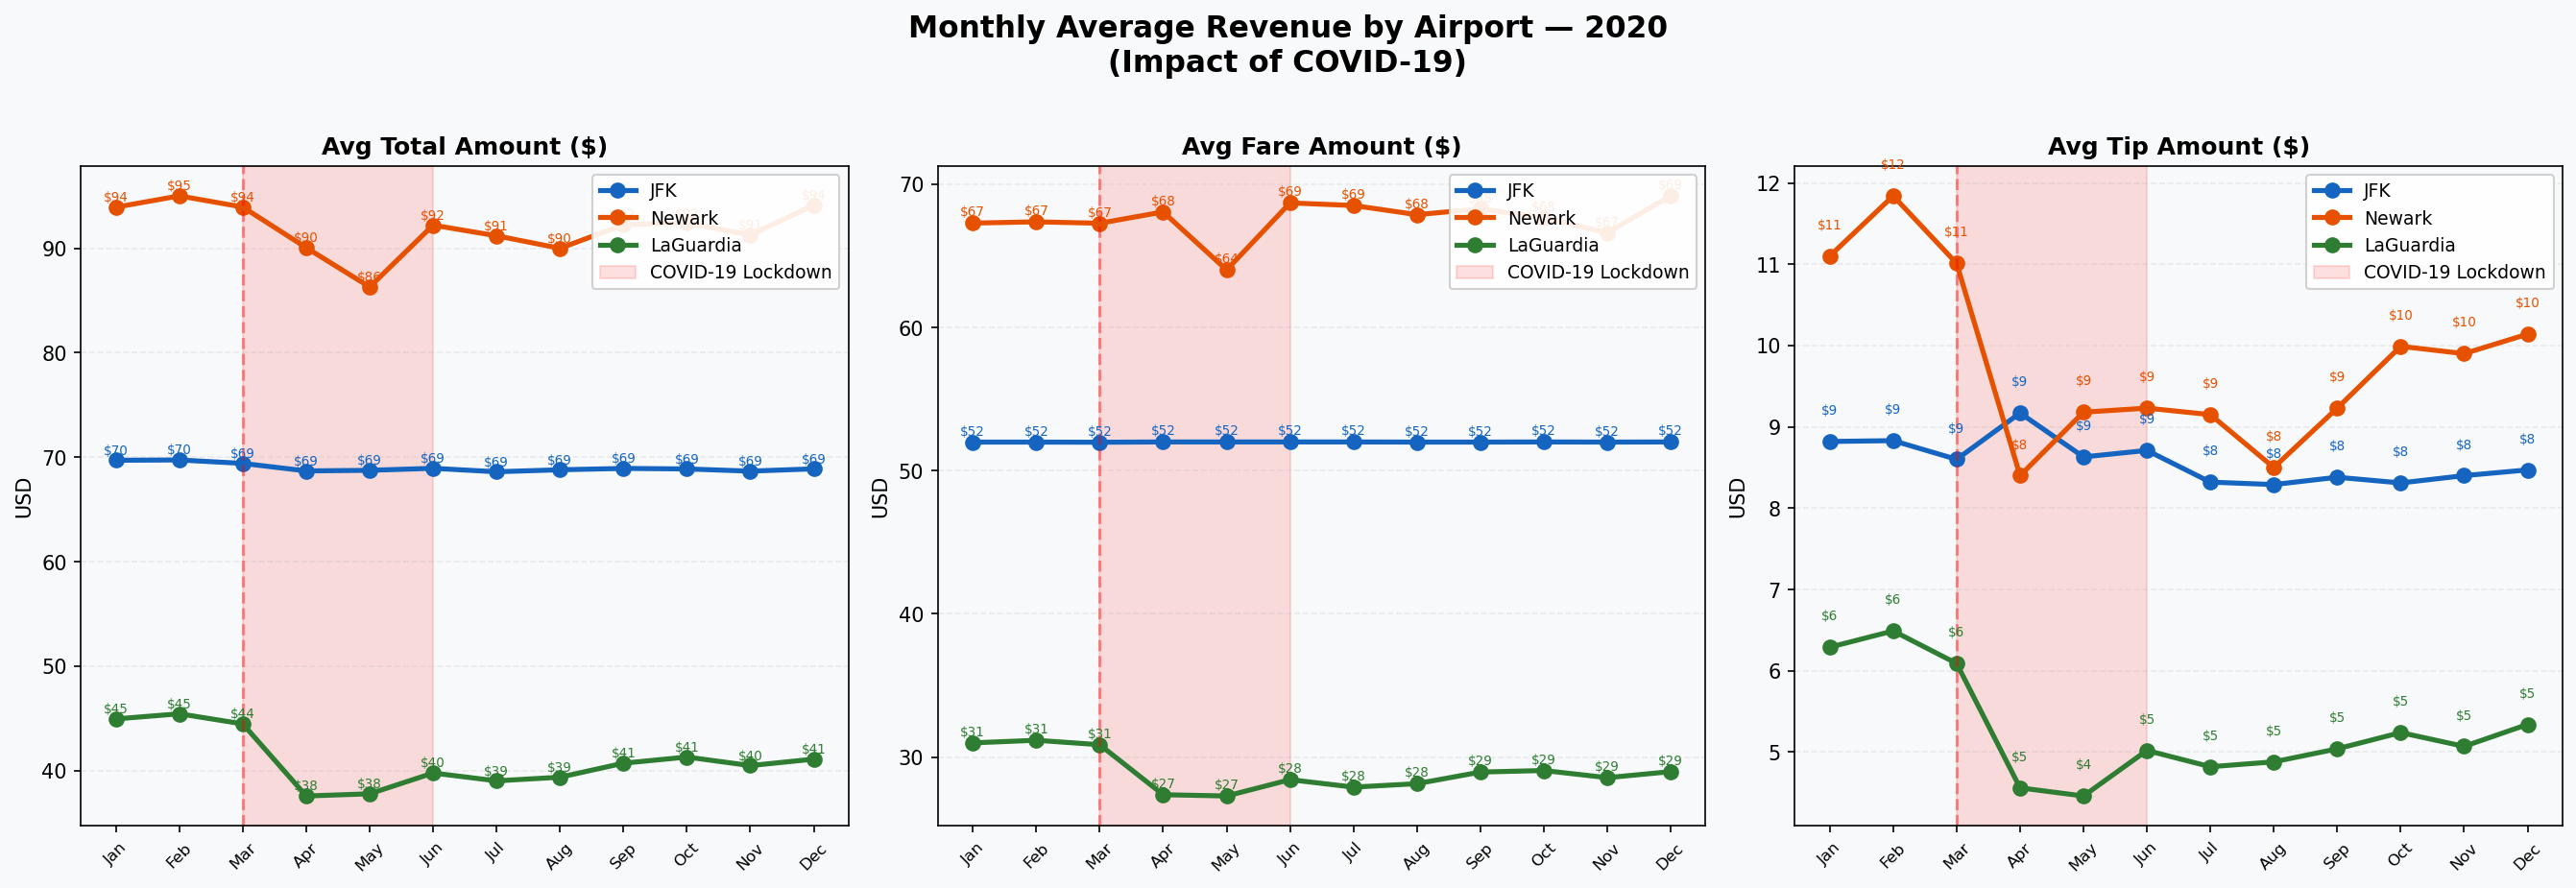

In [ ]:
# Monthly Evolution of Average Revenue by Airport
revenue_monthly = run_query(
    "Monthly Average Revenue by Airport",
    """
    SELECT
        pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END AS airport,
        ROUND(AVG(total_amount), 2) AS avg_revenue,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(tip_amount), 2) AS avg_tip
    FROM taxi
    WHERE RatecodeID IN (2, 3) OR DOLocationID = 138
    GROUP BY pickup_month,
        CASE
            WHEN RatecodeID = 2 THEN 'JFK'
            WHEN RatecodeID = 3 THEN 'Newark'
            WHEN DOLocationID = 138 THEN 'LaGuardia'
        END
    ORDER BY pickup_month
    """
)

pdf = revenue_monthly.toPandas()

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

colors = {"JFK": "#1565C0", "Newark": "#E65100", "LaGuardia": "#2E7D32"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.patch.set_facecolor("#F8F9FA")

metrics = ["avg_revenue", "avg_fare", "avg_tip"]
titles = ["Avg Total Amount ($)", "Avg Fare Amount ($)", "Avg Tip Amount ($)"]

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    ax.set_facecolor("#F8F9FA")

    for airport in ["JFK", "Newark", "LaGuardia"]:
        data = pdf[pdf["airport"] == airport].sort_values("pickup_month")
        ax.plot(data["pickup_month"], data[metric],
                marker="o", linewidth=2.5, markersize=7,
                label=airport, color=colors[airport])

        for _, row in data.iterrows():
            ax.text(row["pickup_month"], row[metric] + 0.3,
                    f"${row[metric]:.0f}",
                    ha="center", va="bottom",
                    fontsize=6.5, color=colors[airport])

    ax.axvspan(3, 6, alpha=0.12, color="red", label="COVID-19 Lockdown")
    ax.axvline(x=3, color="red", linestyle="--", alpha=0.4)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months, fontsize=8, rotation=45)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("USD")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis="y", alpha=0.2, linestyle="--")

fig.suptitle("Monthly Average Revenue by Airport — 2020\n(Impact of COVID-19)",
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("airport_revenue_monthly.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F9FA")
plt.close()

img = PILImage.open("airport_revenue_monthly.png")
display(img)

# **DASHBOARD - Special Fares & Airports**

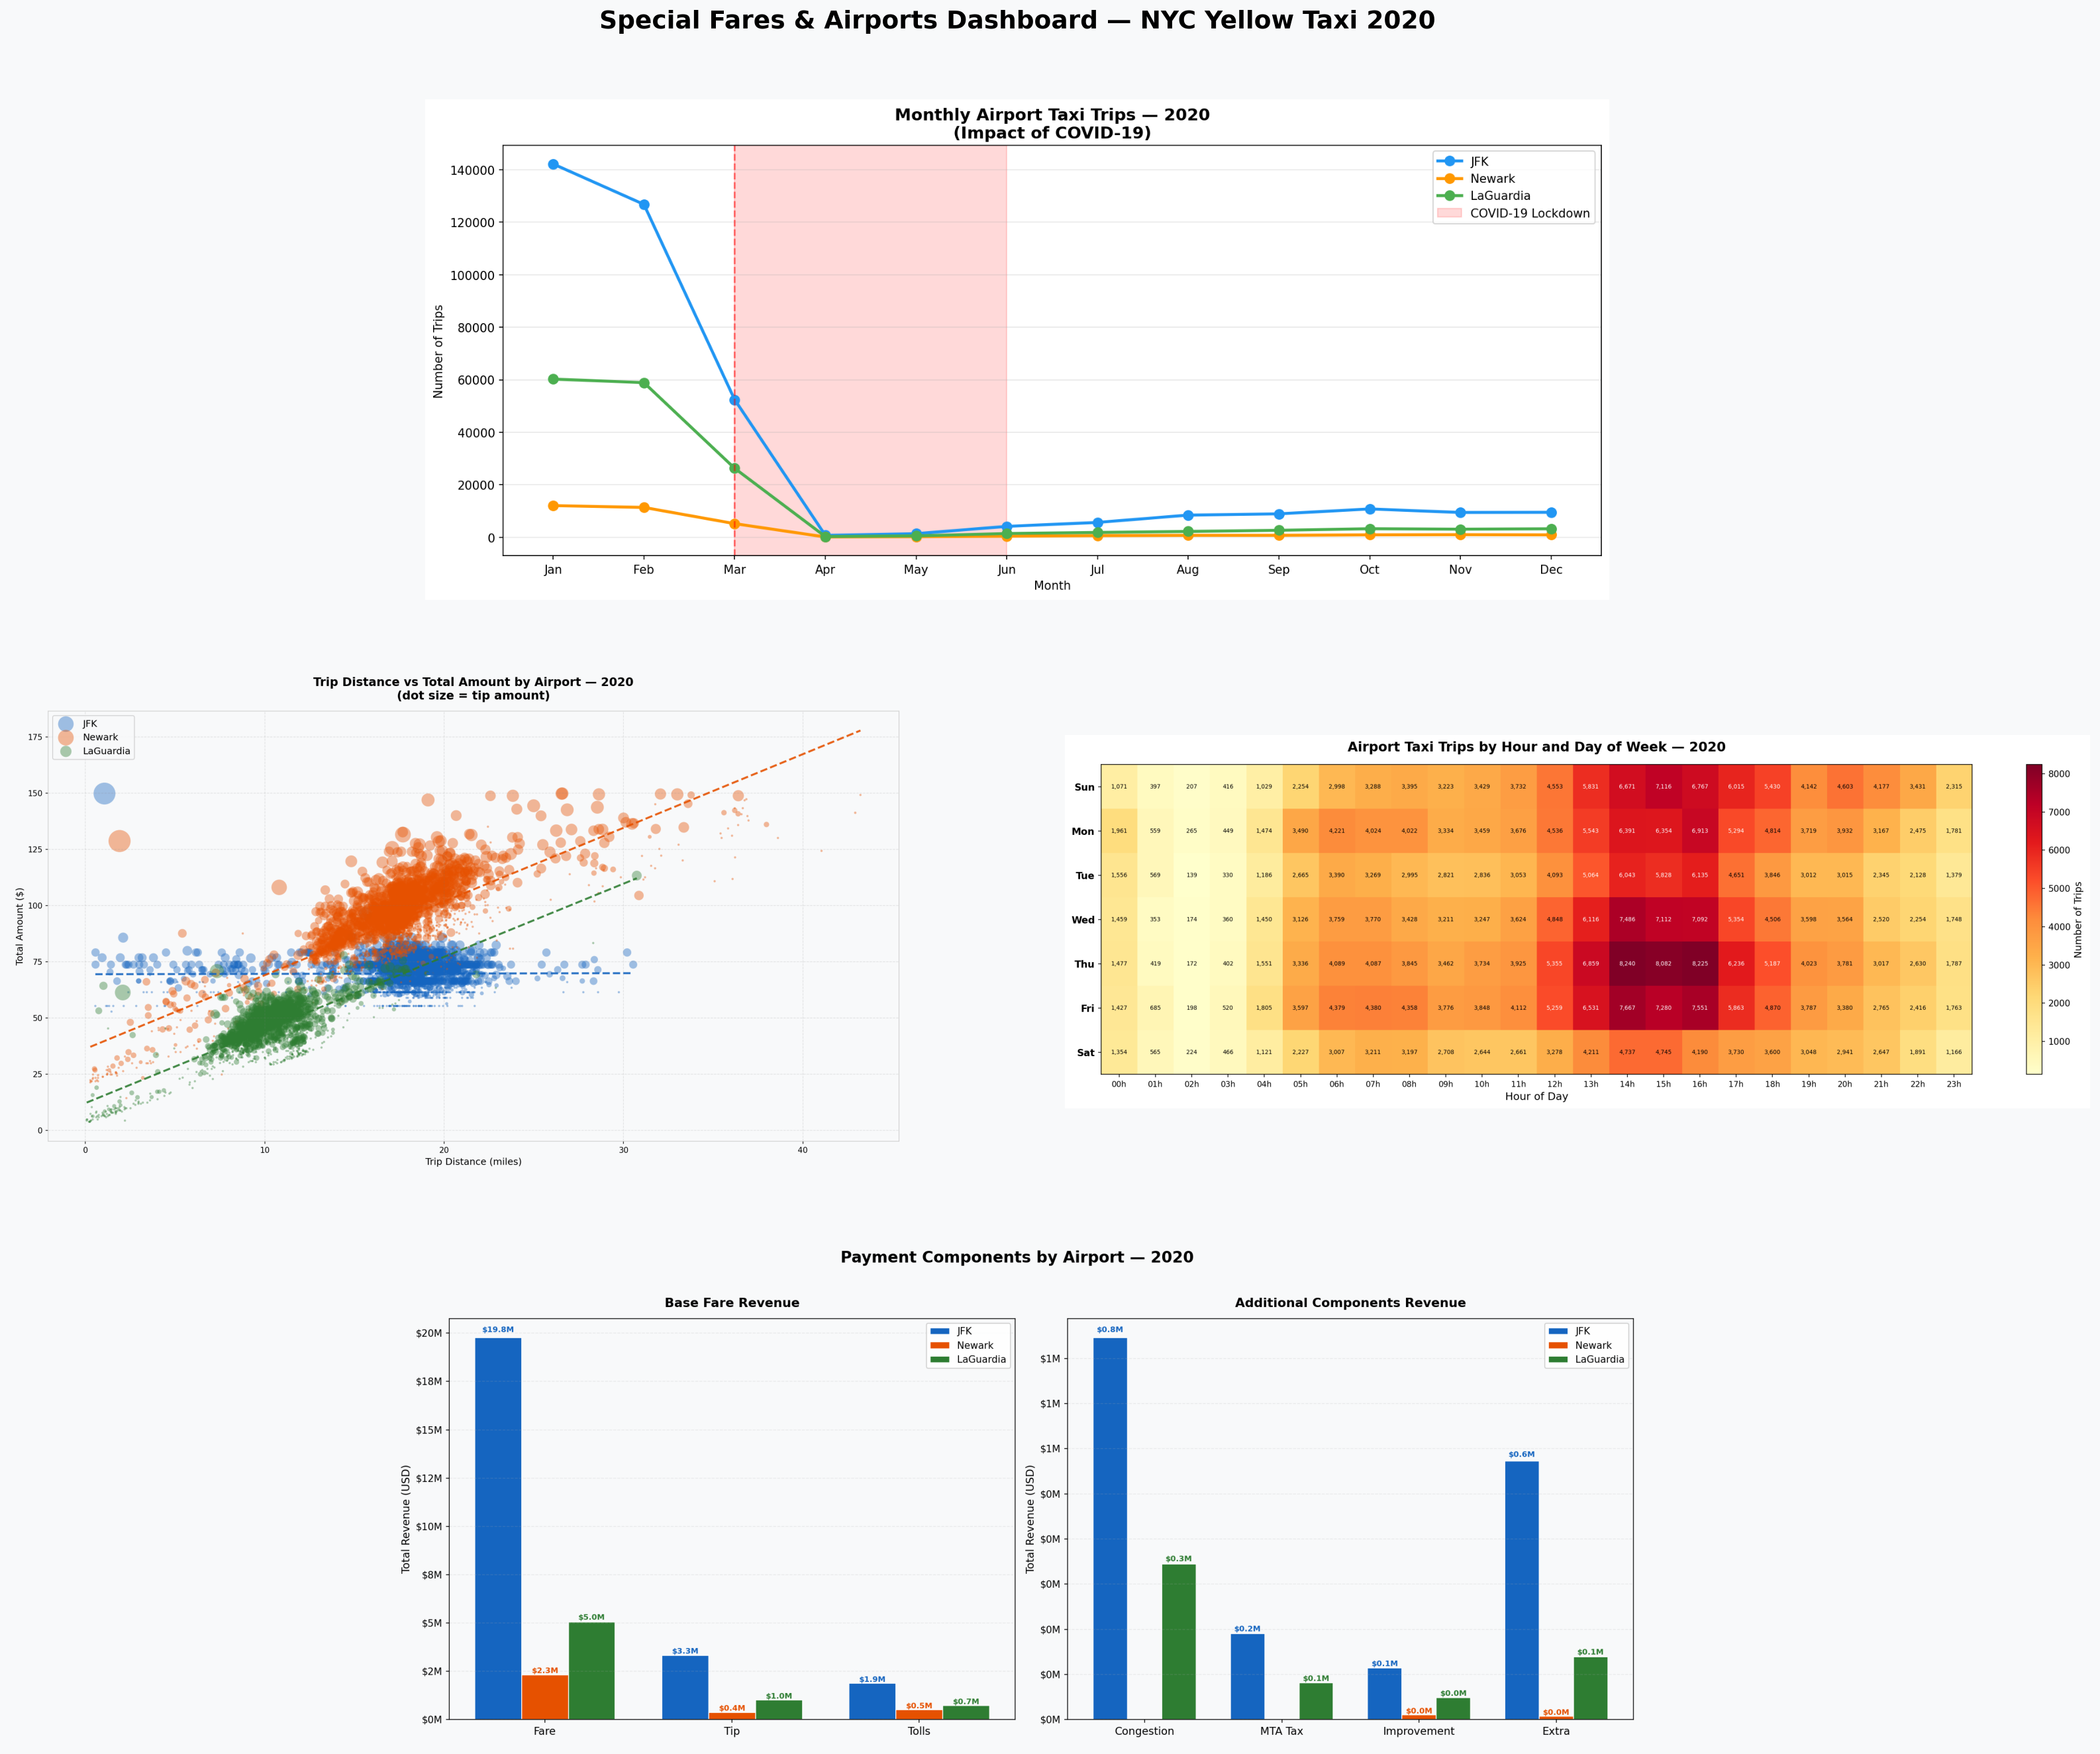

In [101]:
from PIL import Image as PILImage
import numpy as np

# Carrega as imagens já geradas
img1 = PILImage.open("airport_monthly.png")
img2 = PILImage.open("airport_scatter.png")
img3 = PILImage.open("airport_heatmap.png")
img4 = PILImage.open("airport_components_bars.png")

fig = plt.figure(figsize=(24, 18))
fig.patch.set_facecolor("#F8F9FA")

# Plot 1 — full width
ax1 = fig.add_axes([0.05, 0.68, 0.90, 0.28])
ax1.imshow(np.array(img1))
ax1.axis("off")

# Plot 2 e 3
ax2 = fig.add_axes([0.05, 0.36, 0.43, 0.28])
ax2.imshow(np.array(img2))
ax2.axis("off")

ax3 = fig.add_axes([0.52, 0.36, 0.43, 0.28])
ax3.imshow(np.array(img3))
ax3.axis("off")

# Plot 4 — full width
ax4 = fig.add_axes([0.05, 0.04, 0.90, 0.28])
ax4.imshow(np.array(img4))
ax4.axis("off")

fig.suptitle("Special Fares & Airports Dashboard — NYC Yellow Taxi 2020",
             fontsize=18, fontweight="bold", y=1.01)

plt.savefig("dashboard_airports.png", dpi=150, bbox_inches="tight",
            facecolor="#F8F9FA")
plt.close()

dashboard_img = PILImage.open("dashboard_airports.png")
display(dashboard_img)

## **ML Model Example**

In [43]:
# ── Preparação e Cache ───────────────────────────────────────────
features = ["trip_distance", "pickup_hour", "passenger_count",
            "PULocationID", "DOLocationID", "RatecodeID"]

assembler = VectorAssembler(inputCols=features, outputCol="features")
df_ml = assembler.transform(df).select("features", "fare_amount")

df_ml.cache()
df_ml.count()

train, test = df_ml.randomSplit([0.8, 0.2], seed=42)
train.cache()
train.count()

evaluator = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction")

In [44]:
# ── Linear Regression ────────────────────────────────────────────
start_lr = time.time()
lr = LinearRegression(featuresCol="features", labelCol="fare_amount")
lr_model = lr.fit(train)
elapsed_lr = time.time() - start_lr

predictions_lr = lr_model.transform(test)
rmse_lr = evaluator.evaluate(predictions_lr, {evaluator.metricName: "rmse"})
r2_lr   = evaluator.evaluate(predictions_lr, {evaluator.metricName: "r2"})

print(f"Linear Regression → RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f} | Tempo: {elapsed_lr:.2f}s")


26/05/10 13:34:55 WARN Instrumentation: [e5655426] regParam is zero, which might cause numerical instability and overfitting.


Linear Regression → RMSE: 4.7375 | R²: 0.8051 | Tempo: 8.03s


In [45]:
# ── Random Forest ────────────────────────────────────────────────
start_rf = time.time()
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="fare_amount",
    numTrees=50,
    maxDepth=10,
    seed=42
)
rf_model = rf.fit(train)
elapsed_rf = time.time() - start_rf

predictions_rf = rf_model.transform(test)
rmse_rf = evaluator.evaluate(predictions_rf, {evaluator.metricName: "rmse"})
r2_rf   = evaluator.evaluate(predictions_rf, {evaluator.metricName: "r2"})

print(f"Random Forest     → RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f} | Tempo: {elapsed_rf:.2f}s")


26/05/10 13:39:42 WARN DAGScheduler: Broadcasting large task binary with size 1023.1 KiB
26/05/10 13:40:22 WARN DAGScheduler: Broadcasting large task binary with size 1852.9 KiB
26/05/10 13:41:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/05/10 13:42:07 WARN DAGScheduler: Broadcasting large task binary with size 5.7 MiB
26/05/10 13:43:10 WARN DAGScheduler: Broadcasting large task binary with size 1562.8 KiB


Random Forest     → RMSE: 4.5108 | R²: 0.8233 | Tempo: 385.91s


In [46]:
# ── Comparação Final ─────────────────────────────────────────────
print(f"\n{'Modelo':<20} {'RMSE':>10} {'R²':>10} {'Tempo':>10}")
print("-" * 55)
print(f"{'Linear Regression':<20} {rmse_lr:>10.4f} {r2_lr:>10.4f} {elapsed_lr:>9.2f}s")
print(f"{'Random Forest':<20} {rmse_rf:>10.4f} {r2_rf:>10.4f} {elapsed_rf:>9.2f}s")


Modelo                     RMSE         R²      Tempo
-------------------------------------------------------
Linear Regression        4.7375     0.8051      8.03s
Random Forest            4.5108     0.8233    385.91s
